# Paquetes

In [1]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import pickle
from tensorflow.keras.models import load_model

from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
import numpy as np

import pennylane as qml
from pennylane import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import pandas as pd

from sklearn.preprocessing import OneHotEncoder

In [2]:
random_seed=42


# Carga de Datos

In [3]:
with open("data/nopi/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f)
with open("data/nopi/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

df_tr_rad = df_tr[df_tr["image_type"] == "radial"]
df_tr_circ = df_tr[df_tr["image_type"] == "circunferencial"]

train_imgs_tf_rad = train_imgs_tf[df_tr_rad.index]
train_imgs_tf_circ = train_imgs_tf[df_tr_circ.index]

with open("data/nopi/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f)
with open("data/nopi/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

df_val_rad = df_val[df_val["image_type"] == "radial"]
df_val_circ = df_val[df_val["image_type"] == "circunferencial"]

val_imgs_tf_rad = val_imgs_tf[df_val_rad.index]
val_imgs_tf_circ = val_imgs_tf[df_val_circ.index]

with open("data/nopi/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f)
with open("data/nopi/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

df_test_rad = df_test[df_test["image_type"] == "radial"]
df_test_circ = df_test[df_test["image_type"] == "circunferencial"]

test_imgs_tf_rad = test_imgs_tf[df_test_rad.index]
test_imgs_tf_circ = test_imgs_tf[df_test_circ.index]

In [4]:
imgs_tf_rad = np.concatenate([train_imgs_tf_rad, val_imgs_tf_rad])
imgs_tf_circ = np.concatenate([train_imgs_tf_circ, val_imgs_tf_circ])

df_rad = pd.concat([df_tr_rad, df_val_rad], ignore_index=True)
df_circ = pd.concat([df_tr_circ, df_val_circ], ignore_index=True)

# Circuitos Cuánticos

In [5]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [6]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [7]:
q_train_images = load_data_to_cpu("quantum/nopi/train/train_{}.pkl", len(train_imgs_tf))
q_train_images_circ = q_train_images[df_tr_circ.index]
q_train_images_rad = q_train_images[df_tr_rad.index]
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/nopi/validation/val_{}.pkl", len(val_imgs_tf))
q_val_images_circ = q_val_images[df_val_circ.index]
q_val_images_rad = q_val_images[df_val_rad.index]
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/nopi/test/test_{}.pkl", len(test_imgs_tf))
q_test_images_circ = q_test_images[df_test_circ.index]
q_test_images_rad = q_test_images[df_test_rad.index]
print(q_test_images.shape)

q_images_rad = np.concatenate([q_train_images_rad, q_val_images_rad])
q_images_circ = np.concatenate([q_val_images_circ, q_train_images_circ])

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


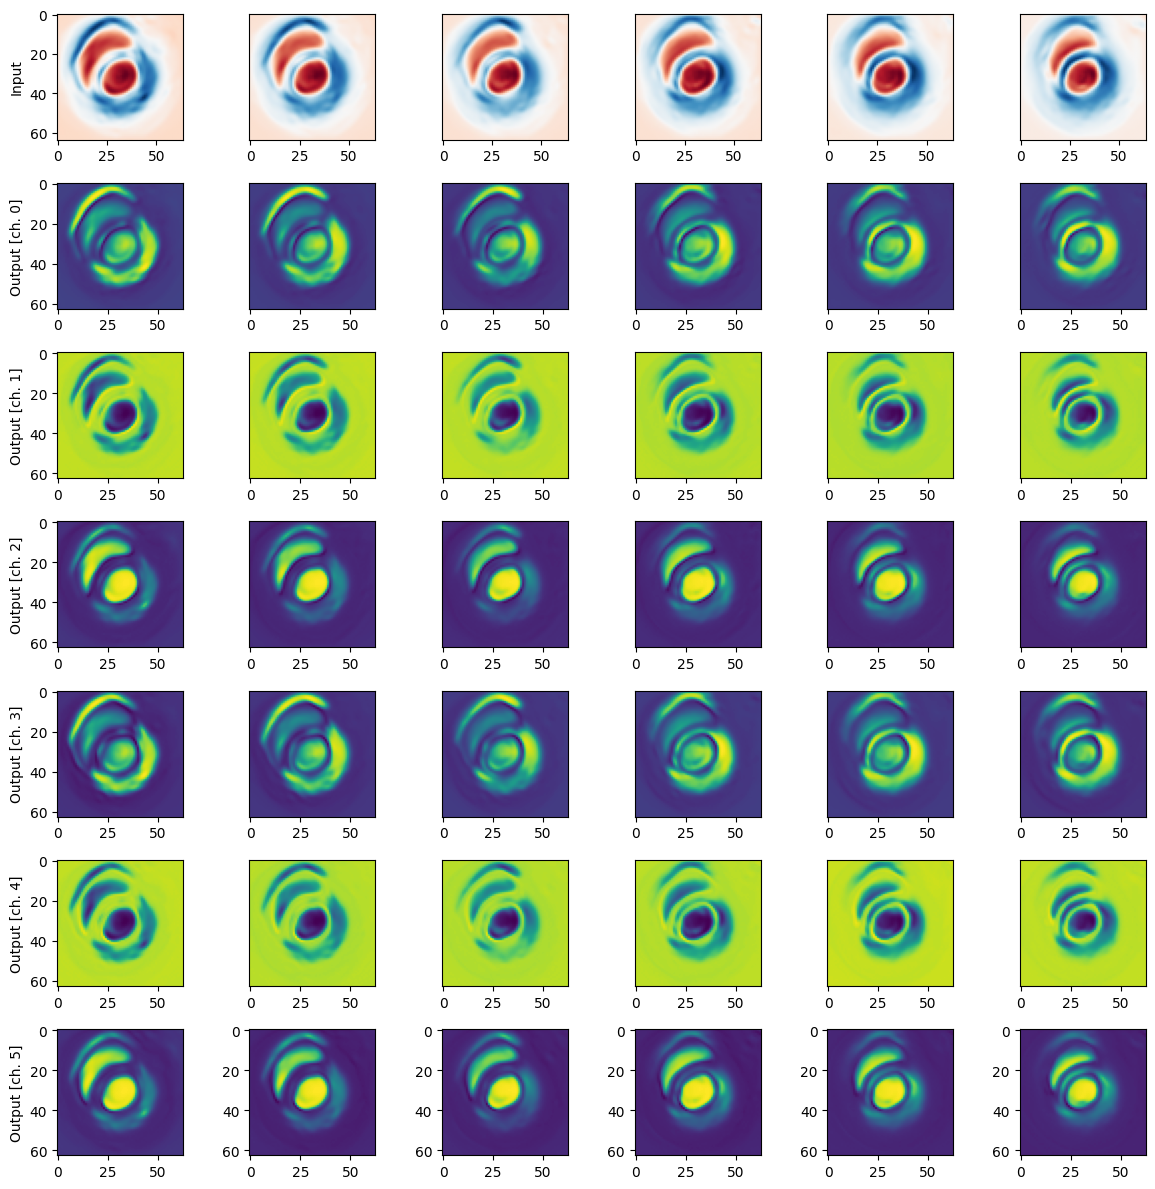

In [8]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, :, : ,c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [9]:
def cnn(input_size: list,learning_rate: float, activation: str, dropout: float, regularization: float, num_classes: int, num_layers: int, num_filters: list, filter_size: int, pool_size:int):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    if len(num_filters) != num_layers:
        raise ValueError("Number of filters and number of layers should be the same.")
    
    layers = [
        keras.layers.Conv3D(24, (2,2,3), strides = 1, activation='relu', input_shape=(input_size[0],input_size[1],3,1)), #Convolucion que sustituye a la cuantica
        keras.layers.Reshape((input_size[0]-1, input_size[1]-1, 24))
        ]
    for i in range(num_layers):
        layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization)))
        layers.append(keras.layers.BatchNormalization(momentum=0.98))
        layers.append(keras.layers.Dropout(dropout))
        layers.append(keras.layers.MaxPooling2D(pool_size=pool_size))
    layers.append(keras.layers.Flatten())
    layers.append(keras.layers.Dense(num_classes, activation="softmax"))

    model = keras.models.Sequential(layers)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def qcnn(input_size: list, learning_rate: float, activation: str, dropout: float, regularization: float, num_classes: int, num_layers: int, num_filters: list, filter_size: int, pool_size:int):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    if len(num_filters) != num_layers:
        raise ValueError("Number of filters and number of layers should be the same.")
    layers = []
    for i in range(num_layers):
        if i == 0:
            layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization), input_shape=(input_size[0]-1,input_size[1]-1,24)))
        else:
            layers.append(keras.layers.Conv2D(num_filters[i], filter_size, strides=1, activation=activation, padding="same", kernel_regularizer=l2(regularization)))
        layers.append(keras.layers.BatchNormalization(momentum=0.98))
        layers.append(keras.layers.Dropout(dropout))
        layers.append(keras.layers.MaxPooling2D(pool_size=pool_size))
    layers.append(keras.layers.Flatten())
    layers.append(keras.layers.Dense(num_classes, activation="softmax"))

    model = keras.models.Sequential(layers)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [10]:
class_names = ["C", "MCA", "MCD", "MU"]

# Function to generate and plot confusion matrices
def plot_confusion_matrices(models, X_test, y_test, class_names):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Convert one-hot encoded labels to class indices
    y_true = np.argmax(y_test, axis=1)
    
    for i, model in enumerate(models):
        # Make predictions
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)

        # Plot confusion matrix
        ax = axes[i]

        for edge in ['top', 'right', 'bottom', 'left']:
            ax.spines[edge].set_visible(False)
        ax.grid(False)

        cm = confusion_matrix(y_true, y_pred)
        cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        cm_display.plot(cmap='Blues', colorbar=True, xticks_rotation='horizontal', ax=ax)

        ax.set_title(f'Model {i+1} Confusion Matrix')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    # Add an overall confusion matrix (ensemble)
    if len(models) > 1:
        ax = axes[5]
        # Ensemble predictions (average probabilities)
        ensemble_preds = np.zeros_like(models[0].predict(X_test, verbose=0))
        for model in models:
            ensemble_preds += model.predict(X_test, verbose=0)
        ensemble_preds /= len(models)
        
        # Get predicted class labels
        ensemble_pred_classes = np.argmax(ensemble_preds, axis=1)
        
        # Compute confusion matrix for ensemble
        cm_ensemble = confusion_matrix(y_true, ensemble_pred_classes)
        
        for edge in ['top', 'right', 'bottom', 'left']:
            ax.spines[edge].set_visible(False)
        ax.grid(False)

        cm = confusion_matrix(y_true, y_pred)
        cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble, display_labels=class_names)
        cm_display.plot(cmap='Blues', colorbar=True, xticks_rotation='horizontal', ax=ax)
        
        axes[5].set_title('Ensemble Model Confusion Matrix')
        axes[5].set_ylabel('True Label')
        axes[5].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()

In [11]:
def pad_history(metric_list, histories):
    max_epochs = max(len(h['loss']) for h in histories)
    return [np.pad(h[metric_list], (0, max_epochs - len(h[metric_list])), constant_values=np.nan) for h in histories]

def plot_metric(metric_array, val_array, title, ylabel):
        epochs = np.arange(metric_array.shape[1])
        
        train_mean = np.nanmean(metric_array, axis=0)
        train_std = np.nanstd(metric_array, axis=0)

        val_mean = np.nanmean(val_array, axis=0)
        val_std = np.nanstd(val_array, axis=0)

        plt.figure(figsize=(12, 6))
        
        # Train
        plt.plot(epochs, train_mean, label='Train (Mean)', color='blue')
        plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)

        # Validation
        plt.plot(epochs, val_mean, label='Validation (Mean)', color='orange')
        plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)

        plt.title(title)
        plt.xlabel('Épocas')
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def plot_ensemble_curve(histories):
    losses = pad_history('loss',histories)
    val_losses = pad_history('val_loss',histories)
    accuracies = pad_history('accuracy',histories)
    val_accuracies = pad_history('val_accuracy',histories)

    losses = np.array(losses)
    val_losses = np.array(val_losses)
    accuracies = np.array(accuracies)
    val_accuracies = np.array(val_accuracies)

    plot_metric(losses, val_losses, 'Curva de Pérdida (Ensemble)', 'Pérdida')
    plot_metric(accuracies, val_accuracies, 'Curva de Precisión (Ensemble)', 'Precisión')

In [12]:
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True, verbose=1)

In [13]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (2784, 63, 63, 24)
q_val_images shape: (800, 63, 63, 24)
train_imgs_tf shape: (2784, 64, 64, 3)
val_imgs_tf shape: (800, 64, 64, 3)


In [14]:
Encoder=OneHotEncoder(sparse=False)
train_labels_circ=Encoder.fit_transform(df_tr_circ["class"].values.reshape(-1, 1))
val_labels_circ=Encoder.fit_transform(df_val_circ["class"].values.reshape(-1, 1))
test_labels_circ=Encoder.fit_transform(df_test_circ["class"].values.reshape(-1, 1))
labels_circ=Encoder.fit_transform(df_circ["class"].values.reshape(-1, 1))

train_labels_rad=Encoder.fit_transform(df_tr_rad["class"].values.reshape(-1, 1))
val_labels_rad=Encoder.fit_transform(df_val_rad["class"].values.reshape(-1, 1))
test_labels_rad=Encoder.fit_transform(df_test_rad["class"].values.reshape(-1, 1))
labels_rad=Encoder.fit_transform(df_rad["class"].values.reshape(-1, 1))

Encoder.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was rename

[array(['C', 'MCA', 'MCD', 'MU'], dtype=object)]

# Datos Radial

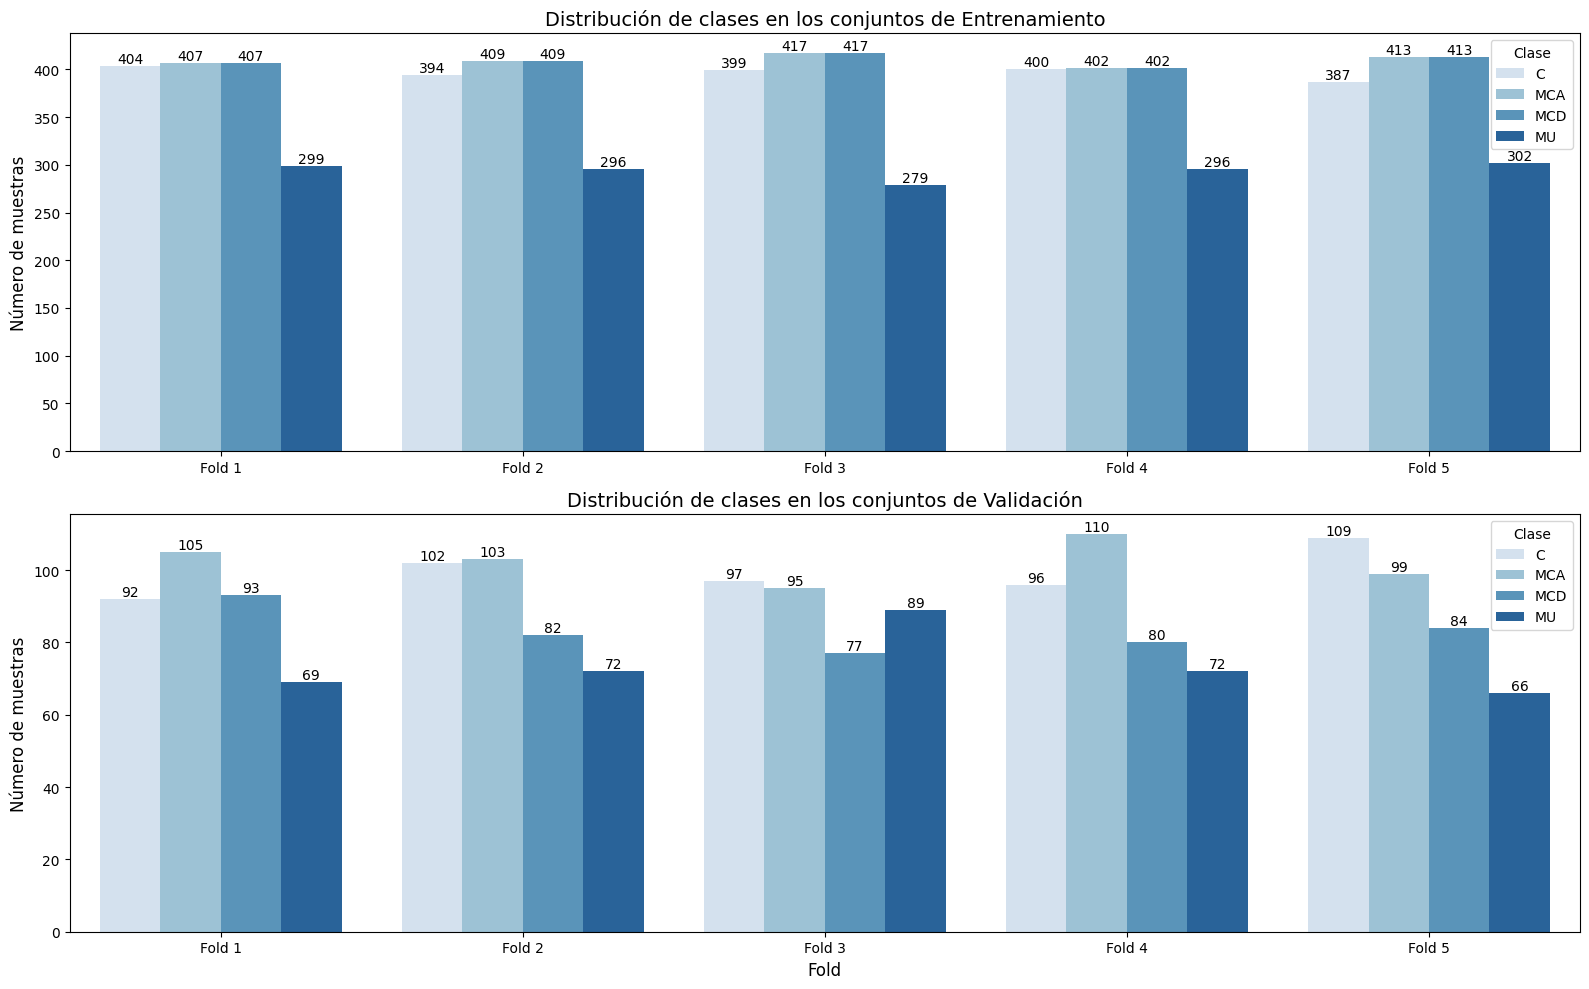

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
import seaborn as sns

class_names = ['C', 'MCA', 'MCD', 'MU']

# Inicializar KFold
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)

train_c_counts = []
train_mca_counts = []
train_mcd_counts = []
train_mu_counts = []
val_c_counts = []
val_mca_counts = []
val_mcd_counts = []
val_mu_counts = []
fold_numbers = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df_rad)):
    y_train_fold = df_rad["class"].values[train_idx]
    y_val_fold = df_rad["class"].values[val_idx]

    train_counts = pd.Series(y_train_fold).value_counts()
    train_c_counts.append(train_counts.get("C", 0))
    train_mca_counts.append(train_counts.get("MCA", 0))
    train_mcd_counts.append(train_counts.get("MCD", 0))
    train_mu_counts.append(train_counts.get("MU", 0))

    val_counts = pd.Series(y_val_fold).value_counts()
    val_c_counts.append(val_counts.get("C", 0))
    val_mca_counts.append(val_counts.get("MCA", 0))
    val_mcd_counts.append(val_counts.get("MCD", 0))
    val_mu_counts.append(val_counts.get("MU", 0))
    
    fold_numbers.append(f"Fold {fold_idx+1}")

df_train = pd.DataFrame({
    'Fold': fold_numbers,
    'C': train_c_counts,
    'MCA': train_mca_counts,
    'MCD': train_mca_counts,
    'MU': train_mu_counts
})

df_val = pd.DataFrame({
    'Fold': fold_numbers,
    'C': val_c_counts,
    'MCA': val_mca_counts,
    'MCD': val_mcd_counts,
    'MU': val_mu_counts
})

df_train_long = pd.melt(df_train, id_vars=['Fold'], value_vars=class_names, 
                        var_name='Clase', value_name='Conteo')
df_val_long = pd.melt(df_val, id_vars=['Fold'], value_vars=class_names, 
                      var_name='Clase', value_name='Conteo')

plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
sns.barplot(x='Fold', y='Conteo', hue='Clase', data=df_train_long, palette='Blues')
plt.title('Distribución de clases en los conjuntos de Entrenamiento', fontsize=14)
plt.ylabel('Número de muestras', fontsize=12)
plt.xlabel('')
plt.legend(title='Clase')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10)

plt.subplot(2, 1, 2)
sns.barplot(x='Fold', y='Conteo', hue='Clase', data=df_val_long, palette='Blues')
plt.title('Distribución de clases en los conjuntos de Validación', fontsize=14)
plt.ylabel('Número de muestras', fontsize=12)
plt.xlabel('Fold', fontsize=12)
plt.legend(title='Clase')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10)

plt.tight_layout()
plt.show()

## QCNN

### KFold

In [ ]:
kf.get_n_splits(q_images_rad,labels_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images_rad,labels_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images_rad[train_idx], q_images_rad[val_idx]
    train_labels, val_labels = labels_rad[train_idx], labels_rad[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=4, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}_4clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=256,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}_4clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

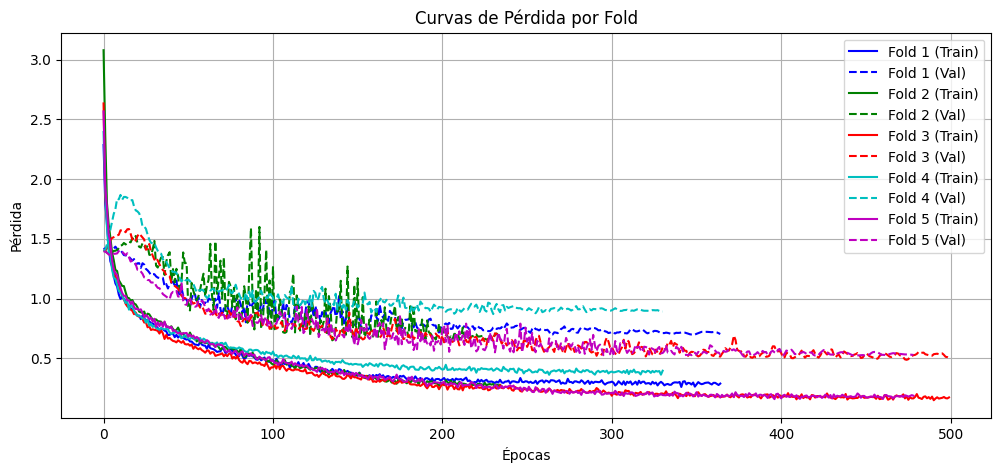

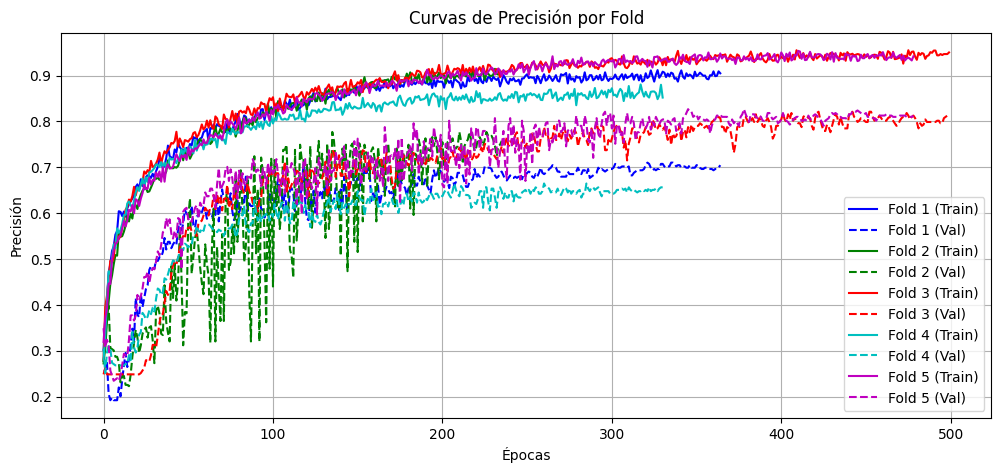

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [ ]:
model_paths = [f"checkpoints/qcnn_fold{i+1}_4clases.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}_4clases.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [ ]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(q_test_images_rad)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels_rad.shape[1]):
        auc = roc_auc_score(test_labels_rad[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_rad[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels_rad, np.round(preds), average='micro')
    acc = accuracy_score(test_labels_rad, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
7/7 [==============================] - 0s 7ms/step
Evaluando fold 2...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 3...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 4...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 5...
7/7 [==============================] - 0s 3ms/step


Graficando resultados del fold 1...


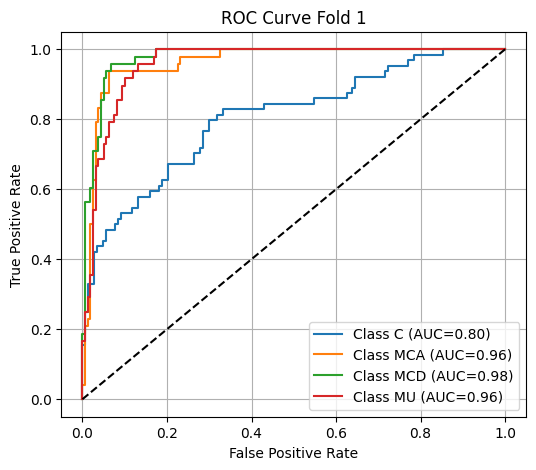

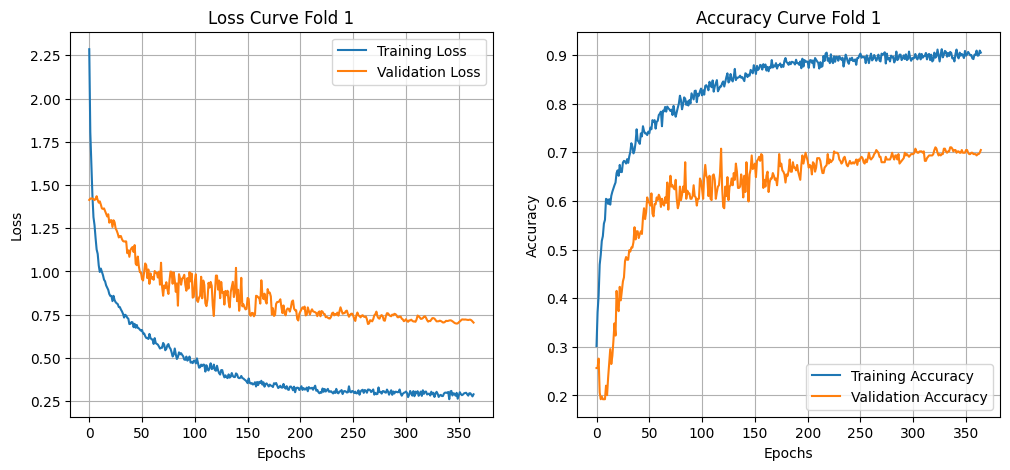

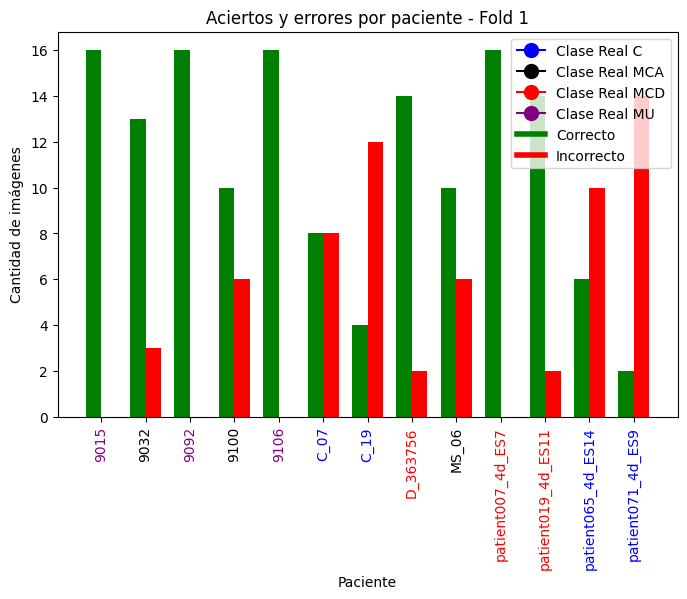

Graficando resultados del fold 2...


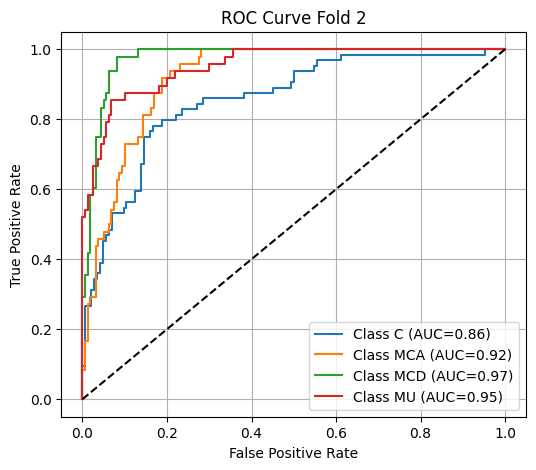

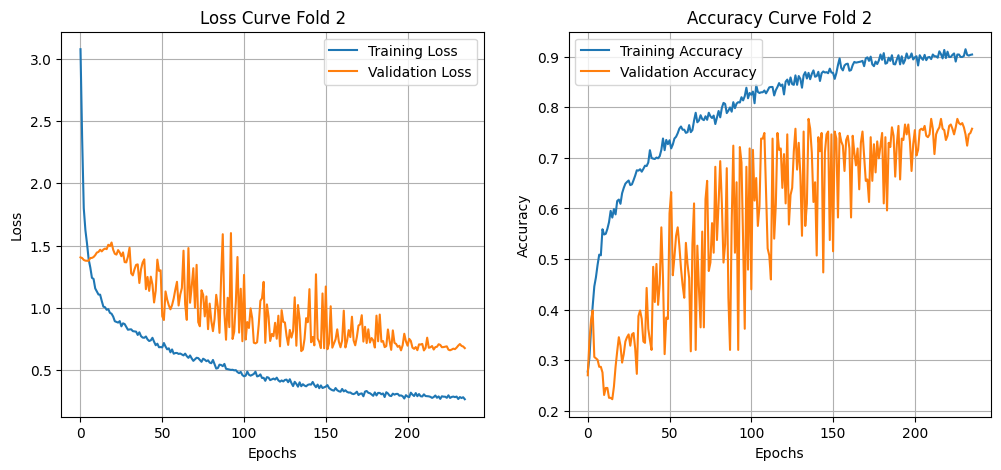

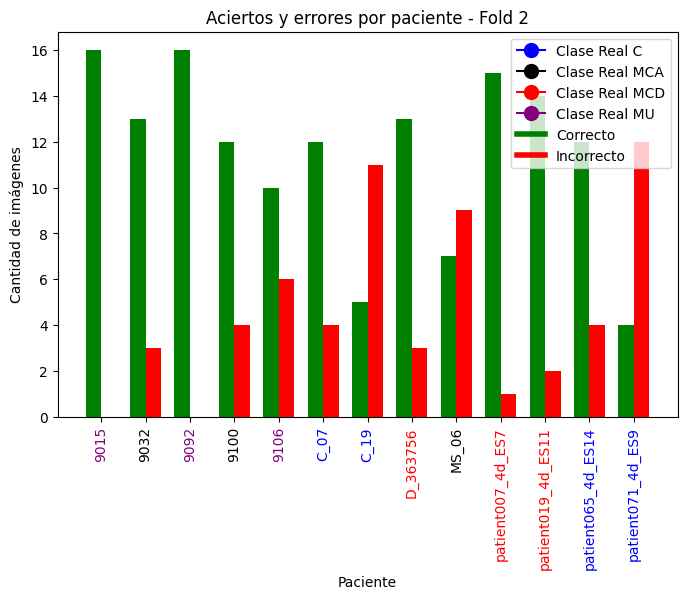

Graficando resultados del fold 3...


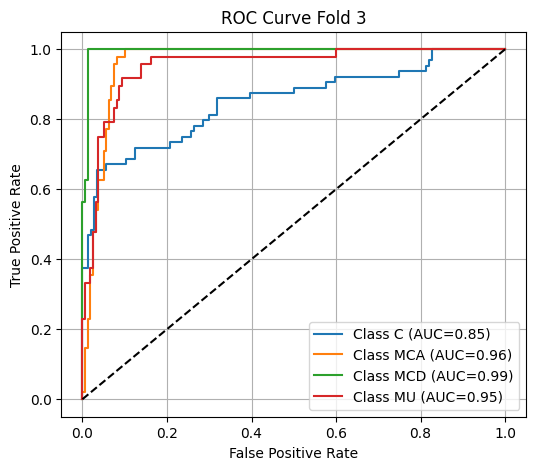

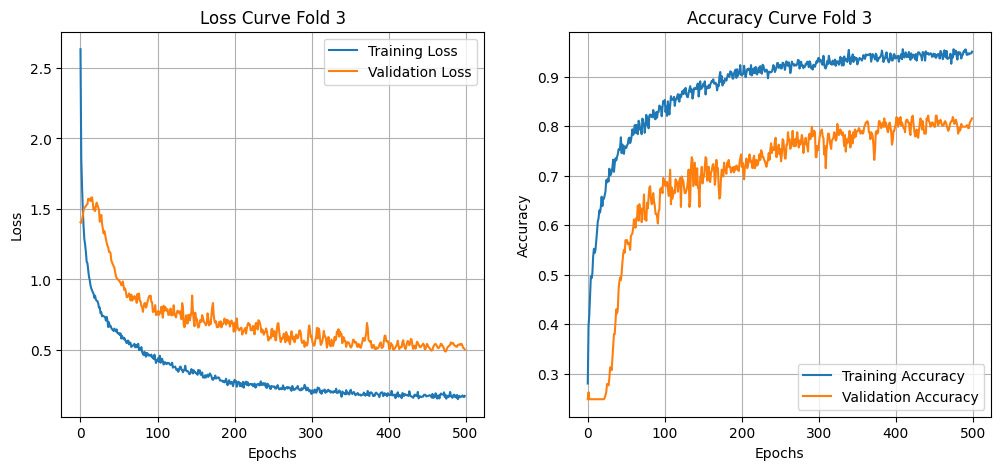

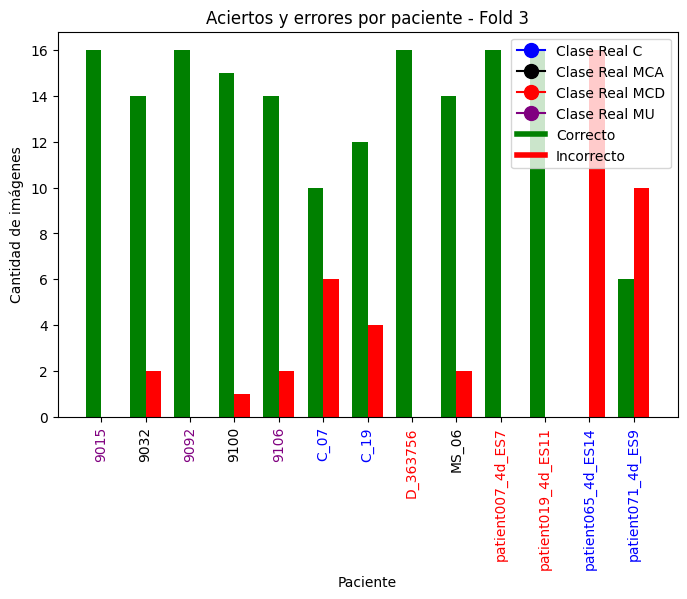

Graficando resultados del fold 4...


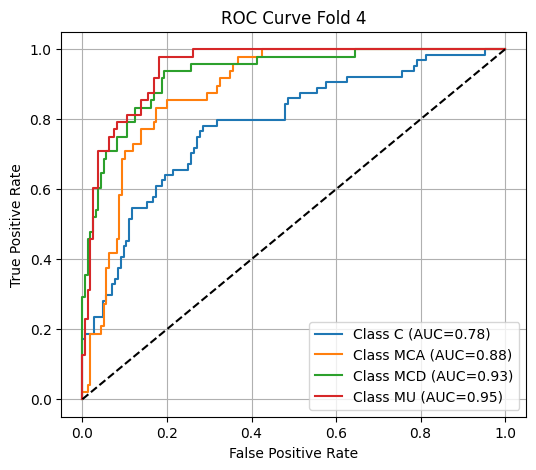

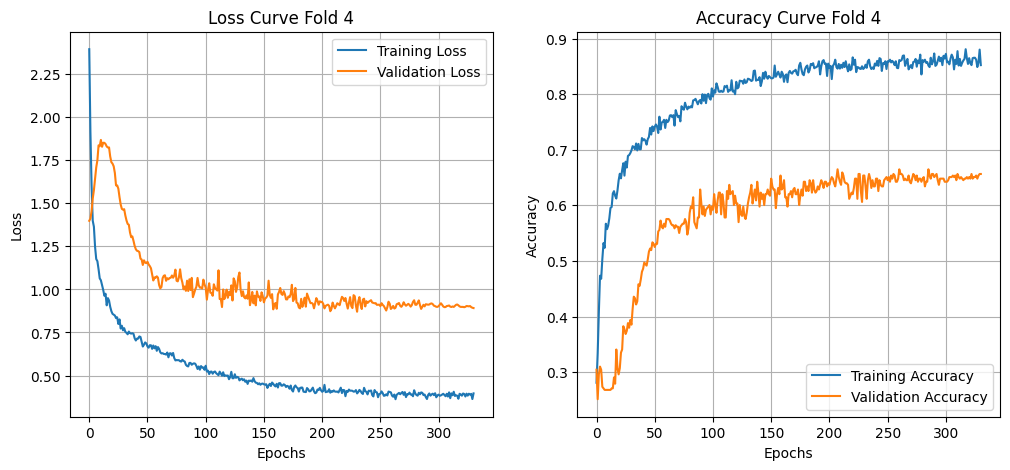

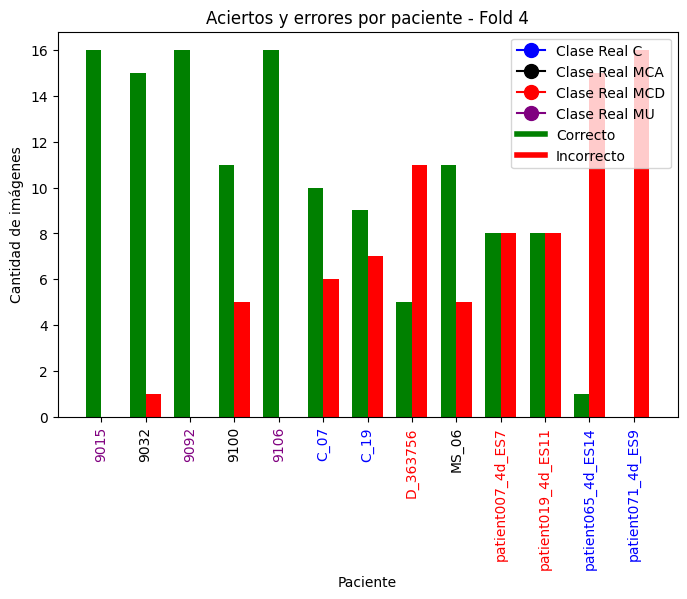

Graficando resultados del fold 5...


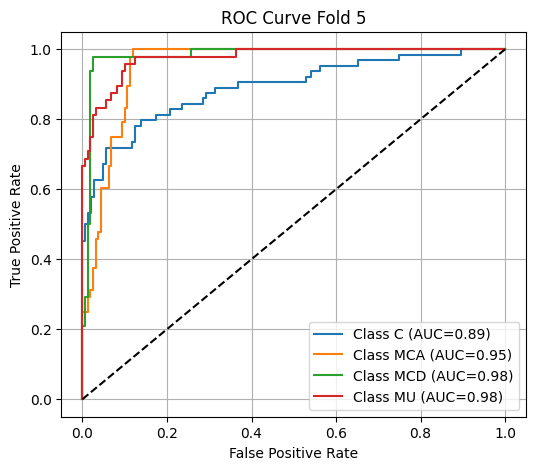

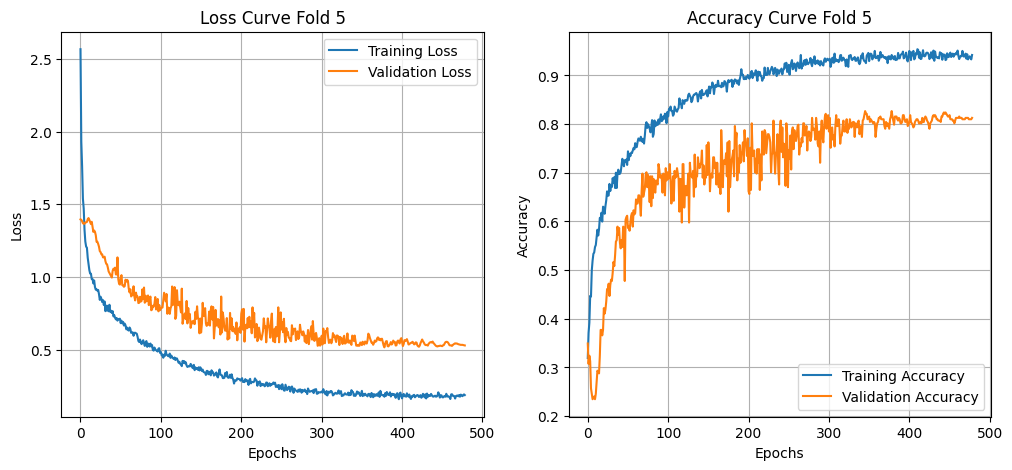

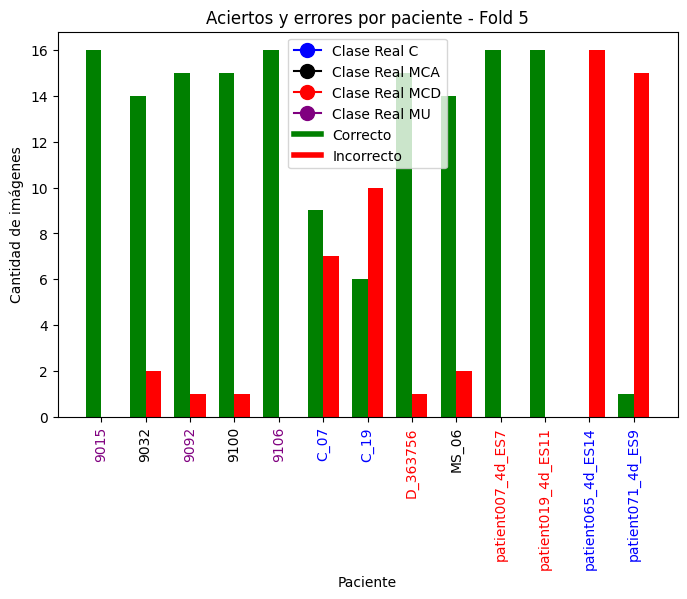

In [ ]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels_rad.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test_rad.copy()
    df["pred"] = [Encoder.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


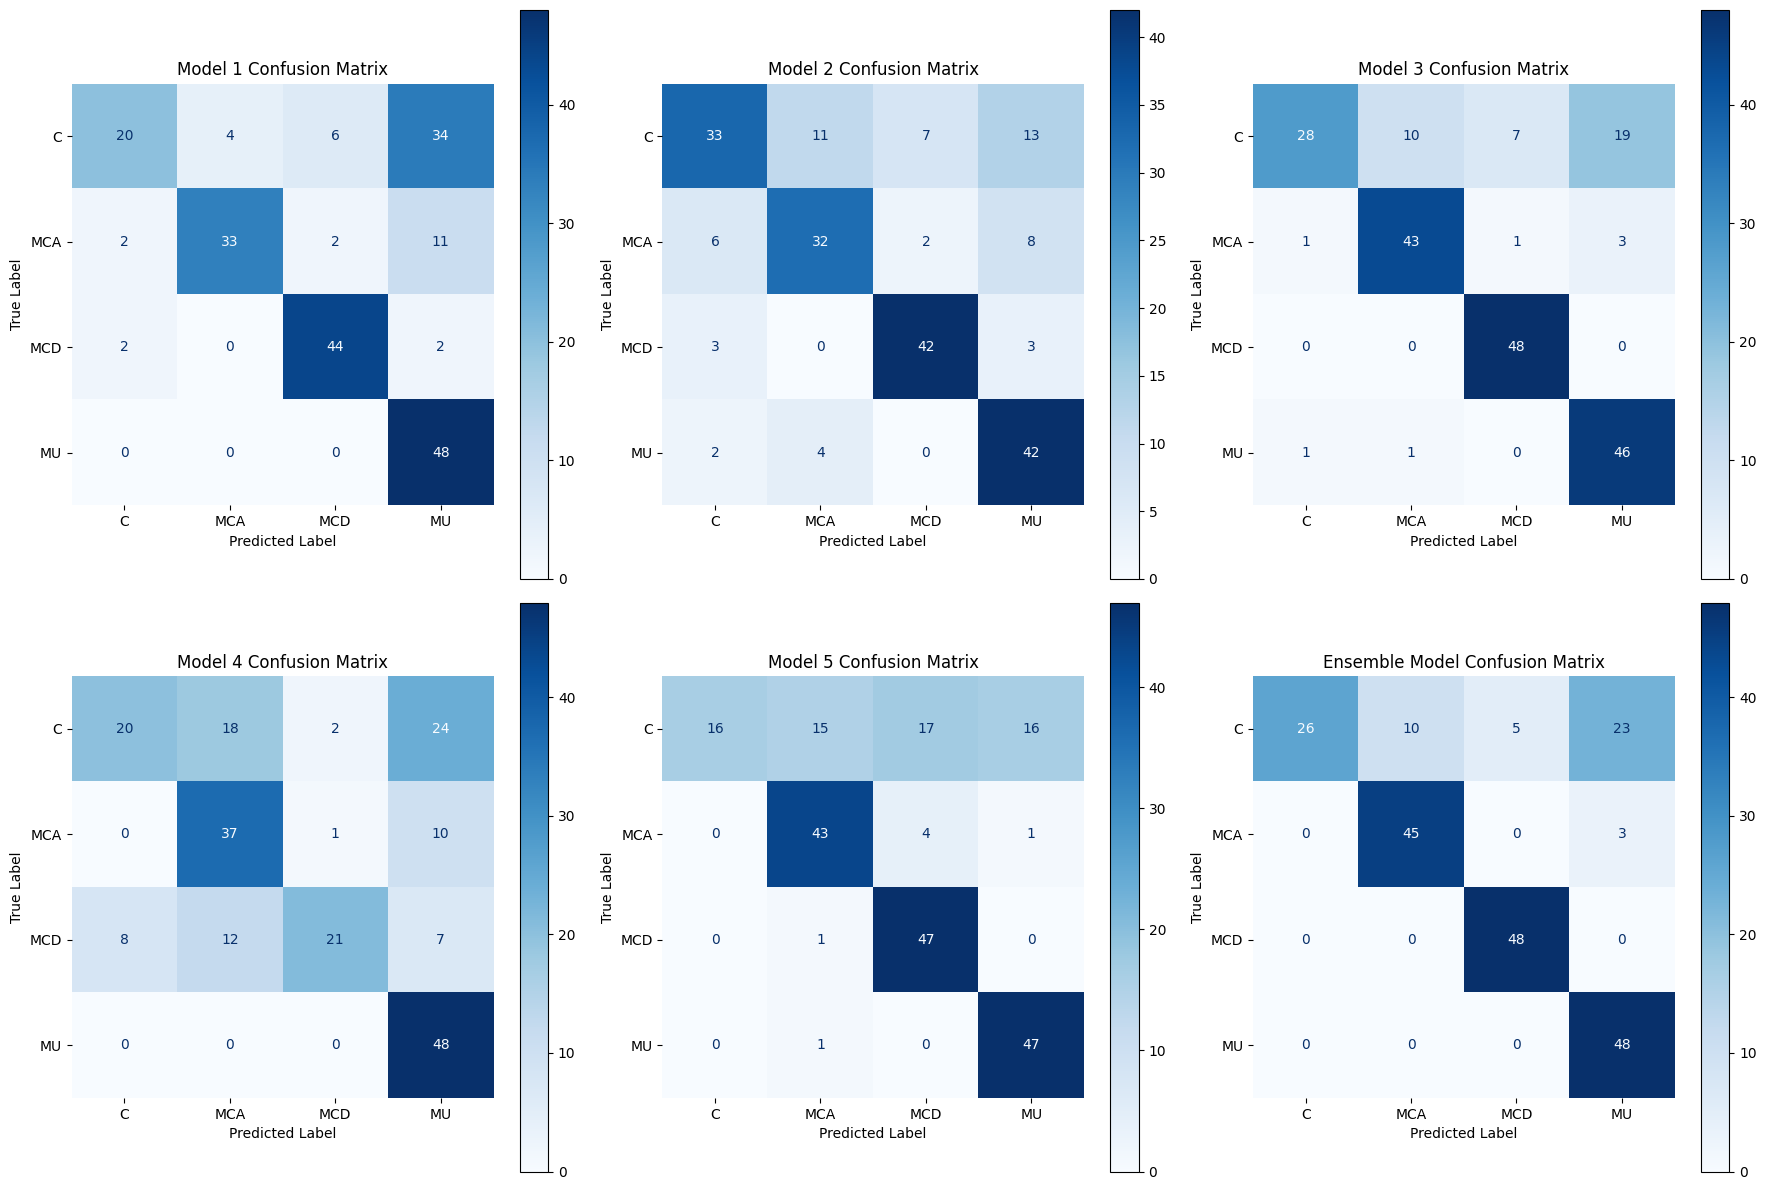

In [ ]:
plot_confusion_matrices(models, q_test_images_rad, test_labels_rad, class_names)

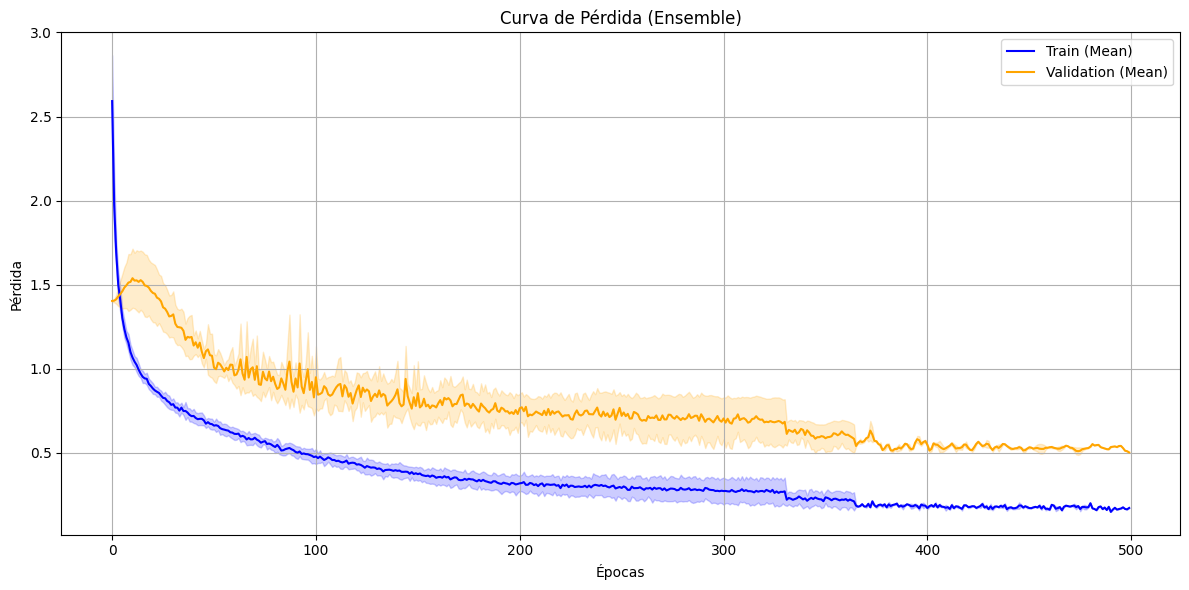

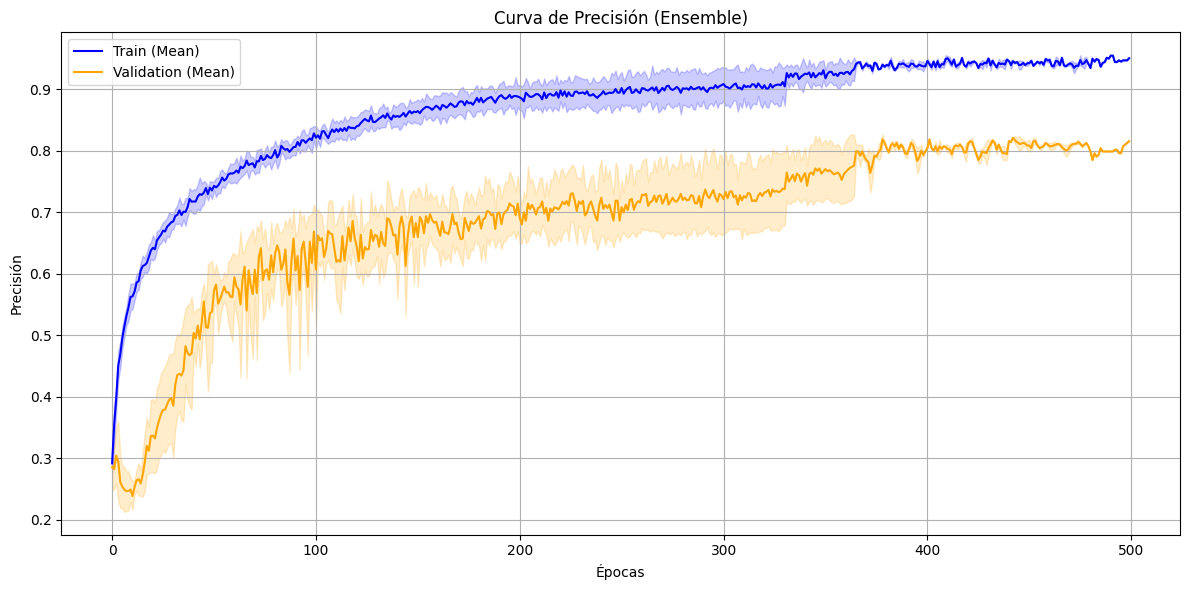

In [ ]:
plot_ensemble_curve(histories)

## CNN

### KFold

In [18]:
kf.get_n_splits(imgs_tf_rad,labels_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf_rad,labels_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf_rad[train_idx], imgs_tf_rad[val_idx]
    train_labels, val_labels = labels_rad[train_idx], labels_rad[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=4, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}_4clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=256,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}_4clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 1.40771, saving model to checkpoints\cnn_fold1_4clases.h5
6/6 - 24s - loss: 2.9567 - accuracy: 0.2861 - val_loss: 1.4077 - val_accuracy: 0.3036 - lr: 0.0010 - 24s/epoch - 4s/step
Epoch 2/500

Epoch 2: val_loss improved from 1.40771 to 1.40714, saving model to checkpoints\cnn_fold1_4clases.h5
6/6 - 0s - loss: 2.5416 - accuracy: 0.2722 - val_loss: 1.4071 - val_accuracy: 0.2563 - lr: 0.0010 - 261ms/epoch - 43ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 1.40714
6/6 - 0s - loss: 2.1279 - accuracy: 0.3224 - val_loss: 1.4111 - val_accuracy: 0.2618 - lr: 0.0010 - 210ms/epoch - 35ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.40714
6/6 - 0s - loss: 1.9760 - accuracy: 0.3580 - val_loss: 1.4237 - val_accuracy: 0.2563 - lr: 0.0010 - 198ms/epoch - 33ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 1.40714
6/6 - 0s - loss: 1.7956 - accuracy: 0.3761 - val_loss: 1.4395 - val_accuracy: 0.

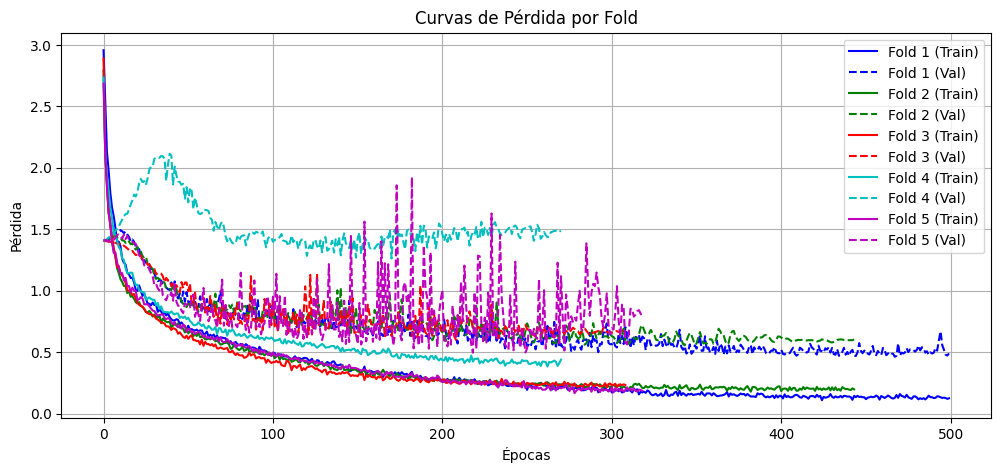

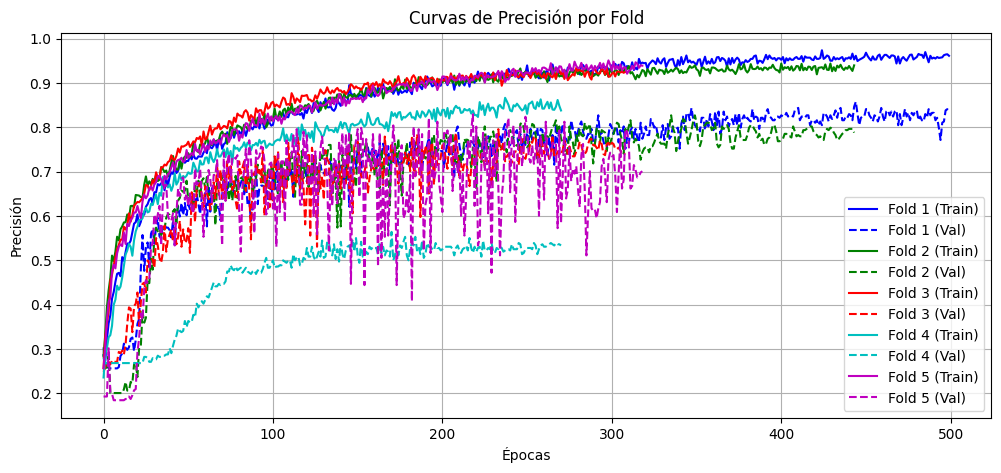

In [19]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [20]:
model_paths = [f"checkpoints/cnn_fold{i+1}_4clases.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}_4clases.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [21]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(test_imgs_tf_rad)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels_rad.shape[1]):
        auc = roc_auc_score(test_labels_rad[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_rad[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels_rad, np.round(preds), average='micro')
    acc = accuracy_score(test_labels_rad, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
7/7 [==============================] - 0s 6ms/step
Evaluando fold 2...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 3...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 4...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 5...
7/7 [==============================] - 0s 2ms/step


Graficando resultados del fold 1...


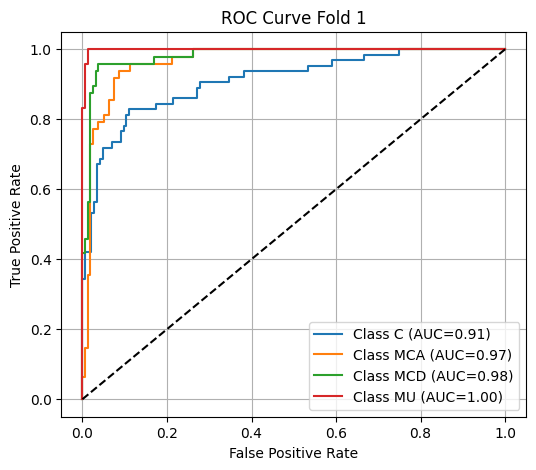

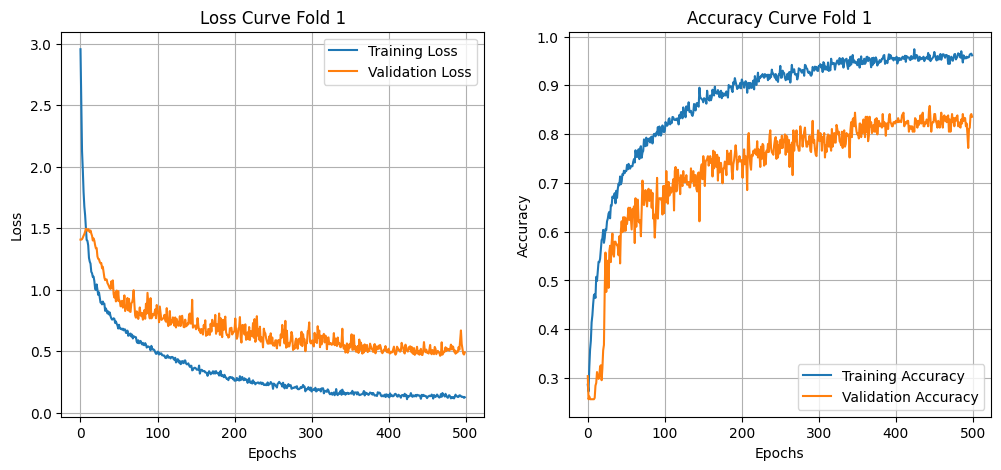

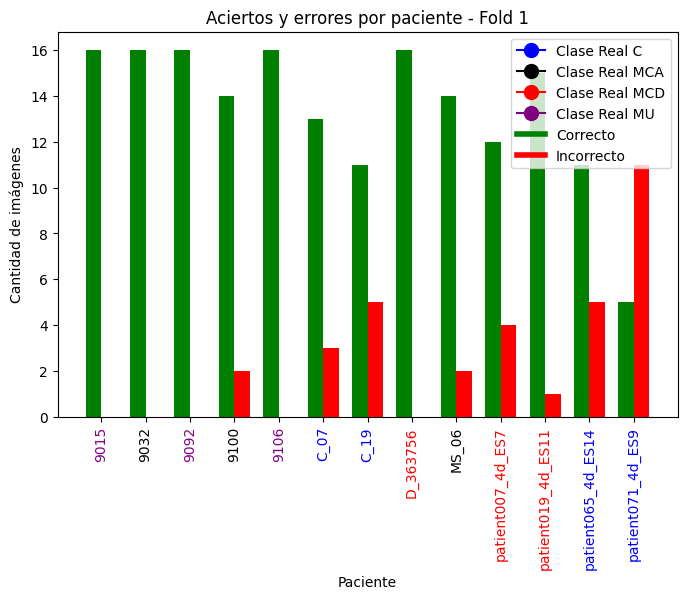

Graficando resultados del fold 2...


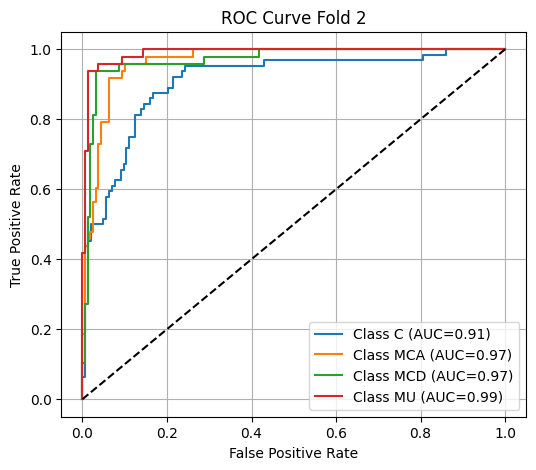

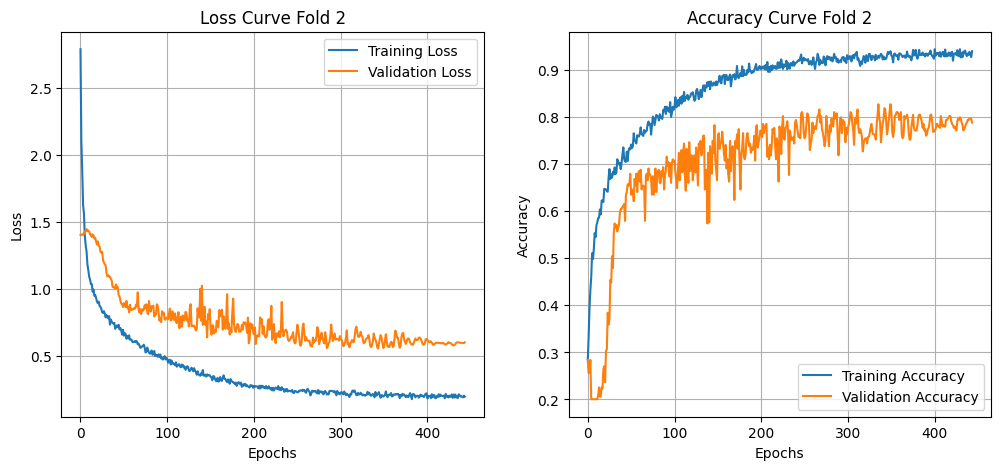

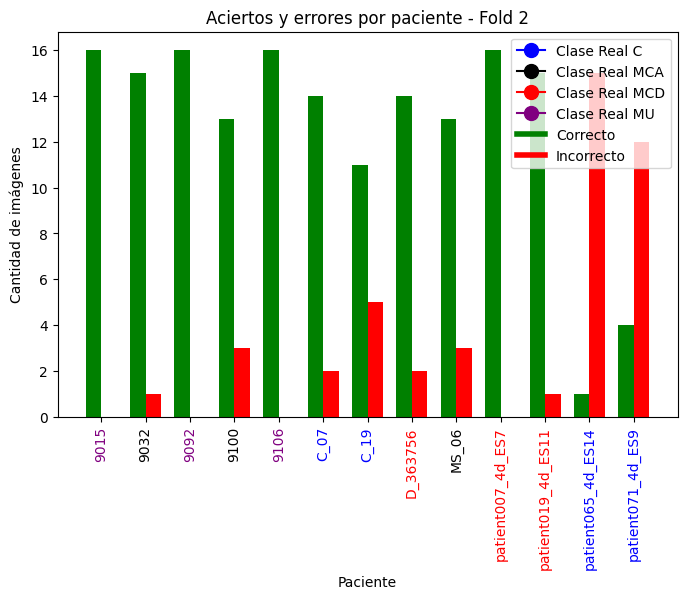

Graficando resultados del fold 3...


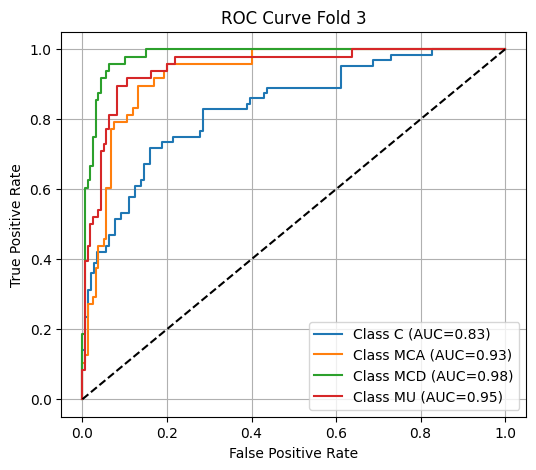

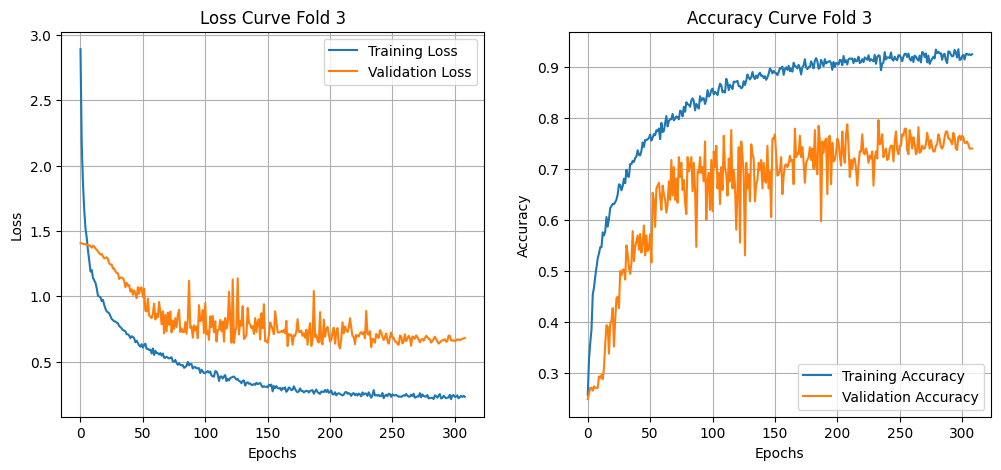

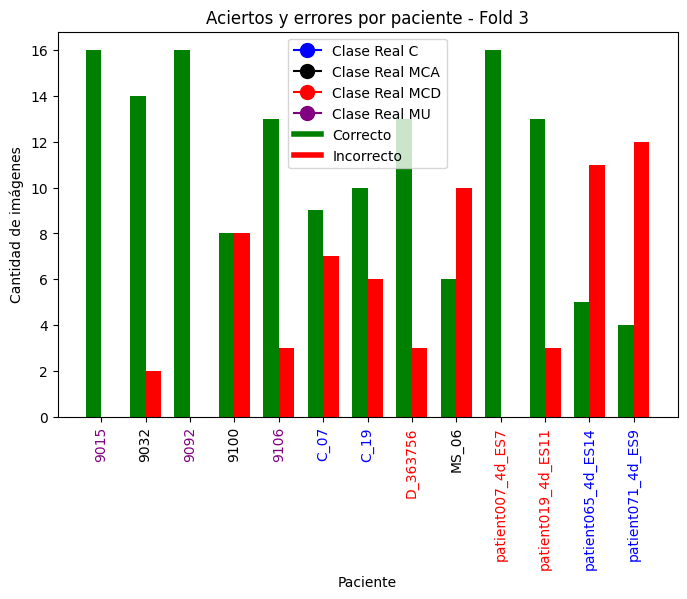

Graficando resultados del fold 4...


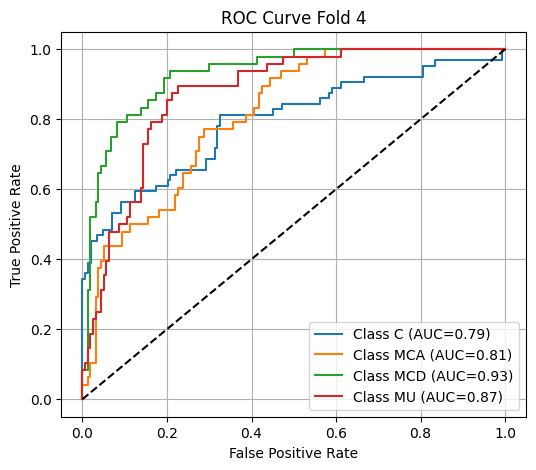

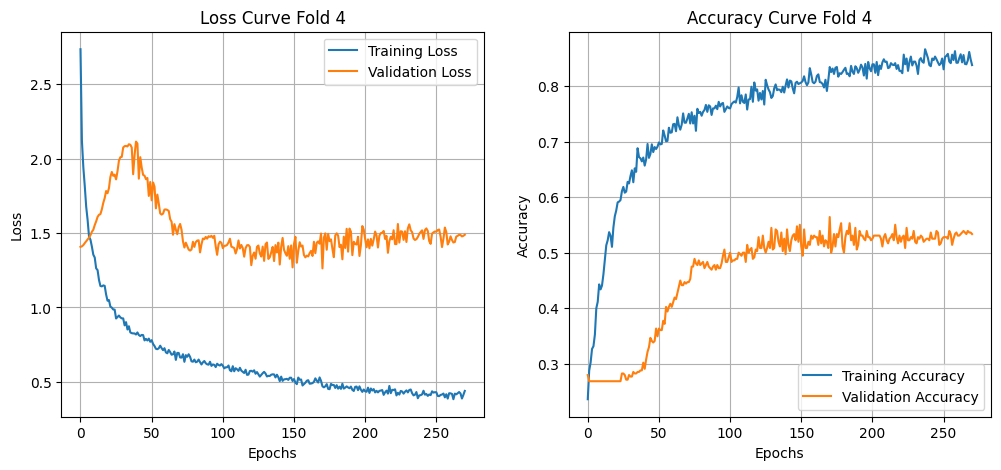

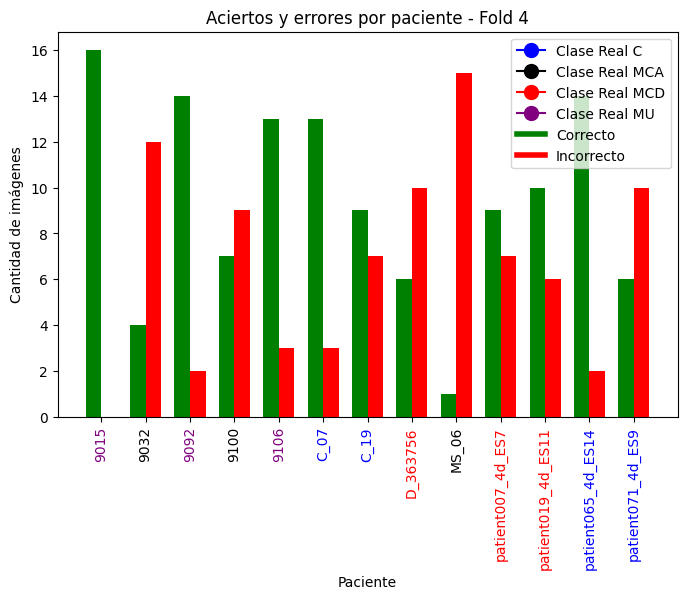

Graficando resultados del fold 5...


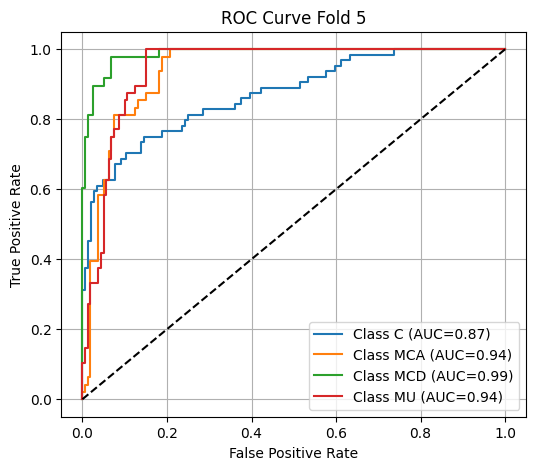

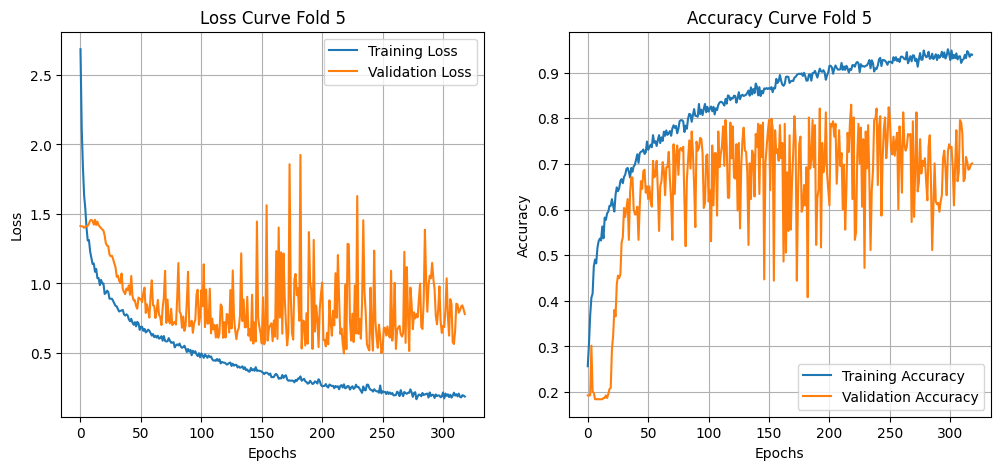

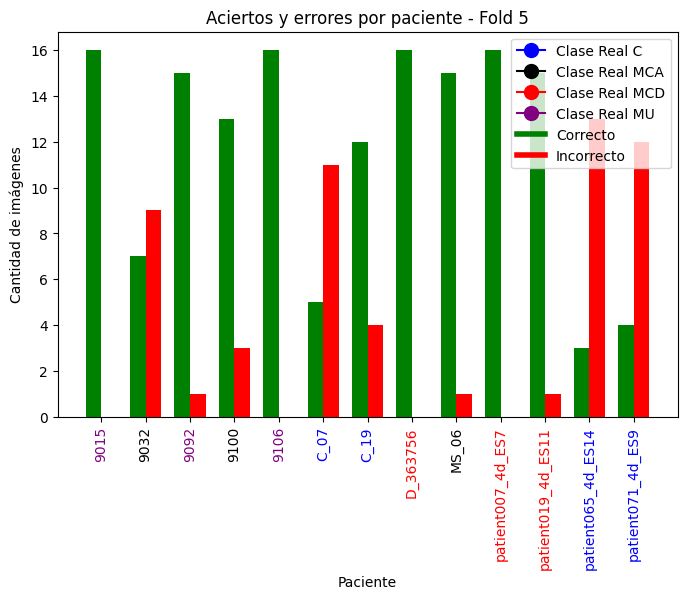

In [22]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels_rad.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test_rad.copy()
    df["pred"] = [Encoder.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


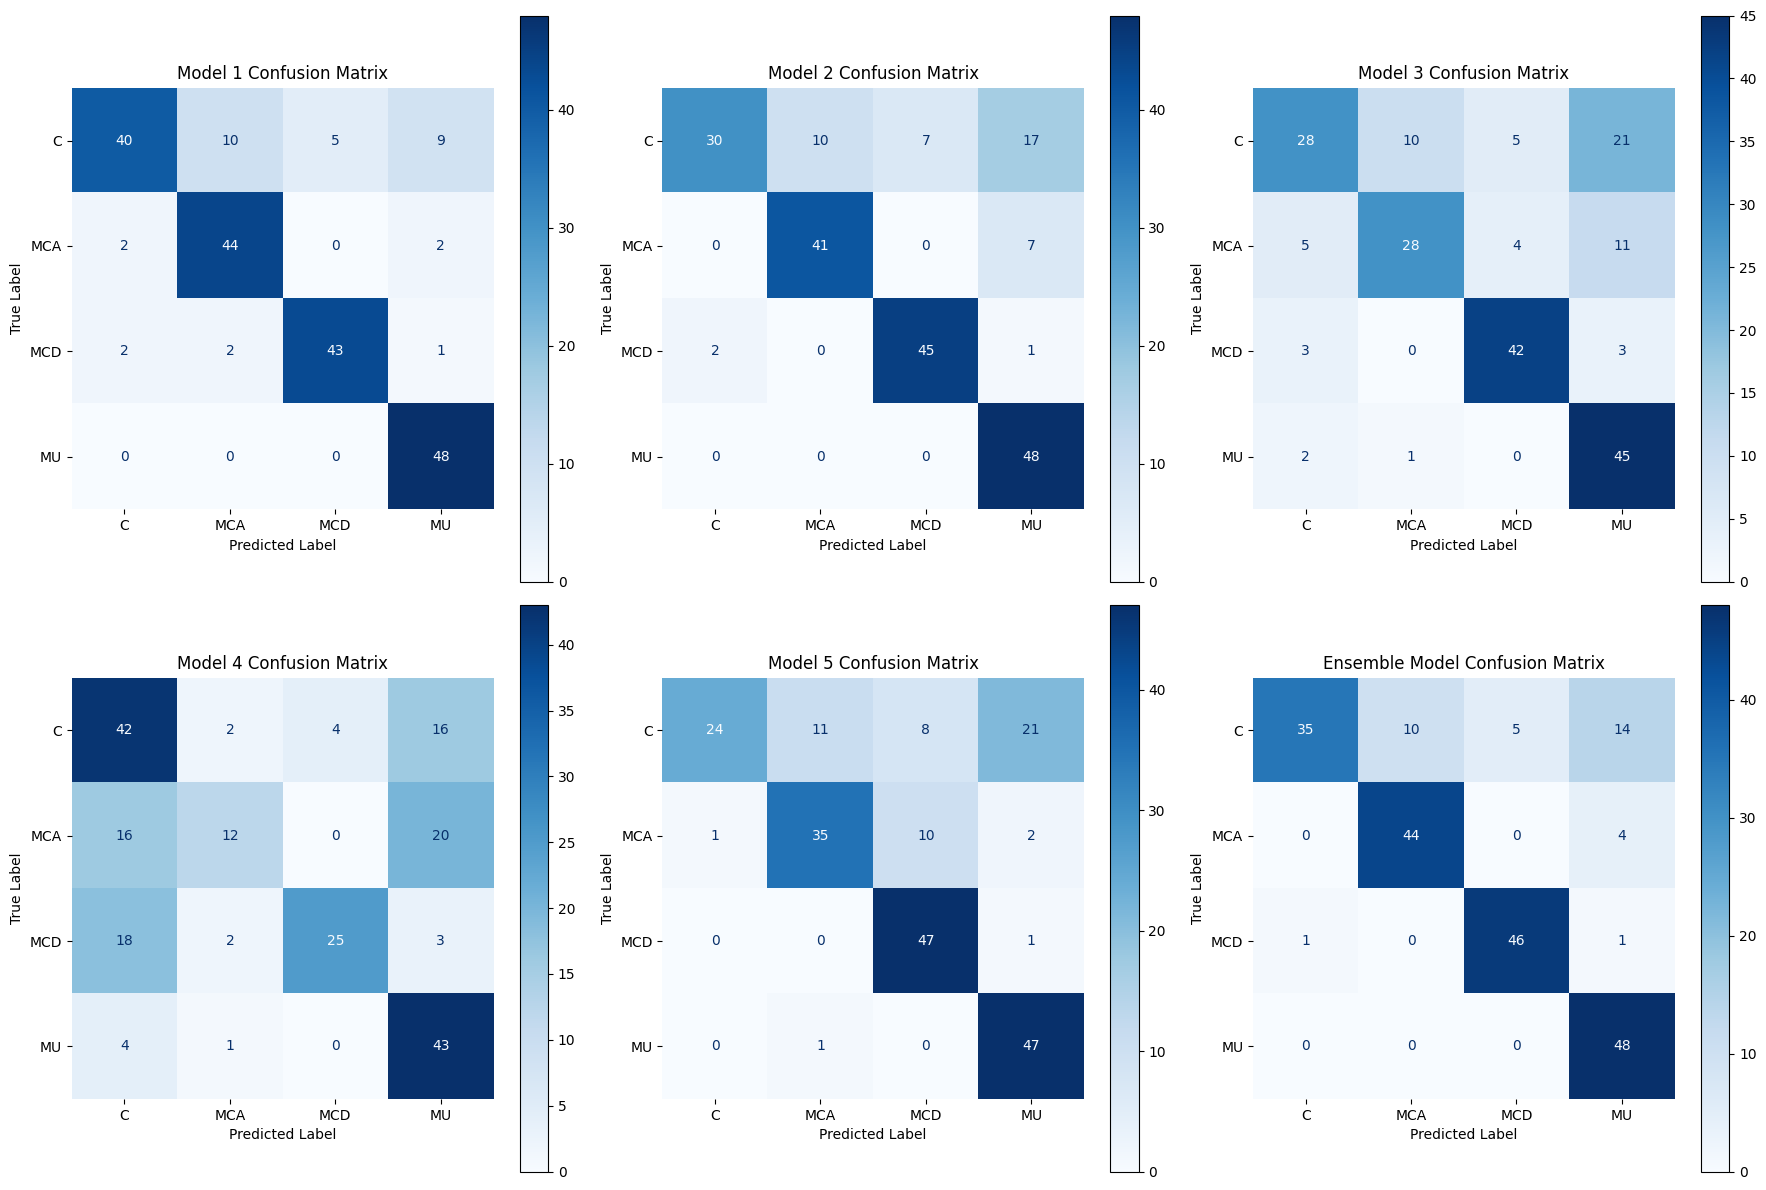

In [23]:
plot_confusion_matrices(models, test_imgs_tf_rad, test_labels_rad, class_names)

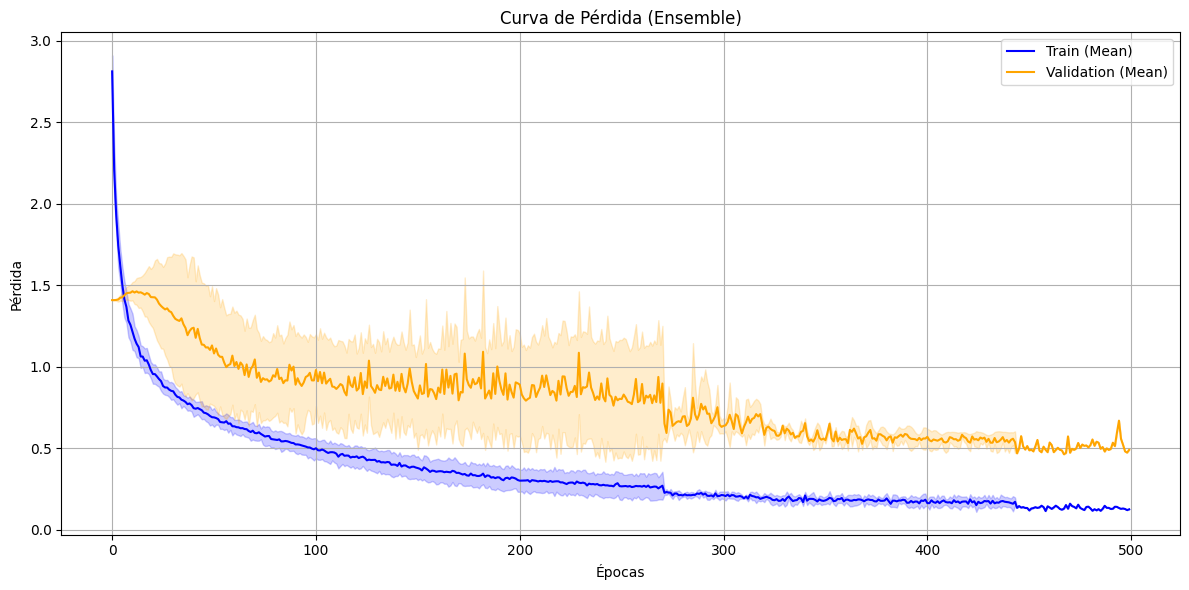

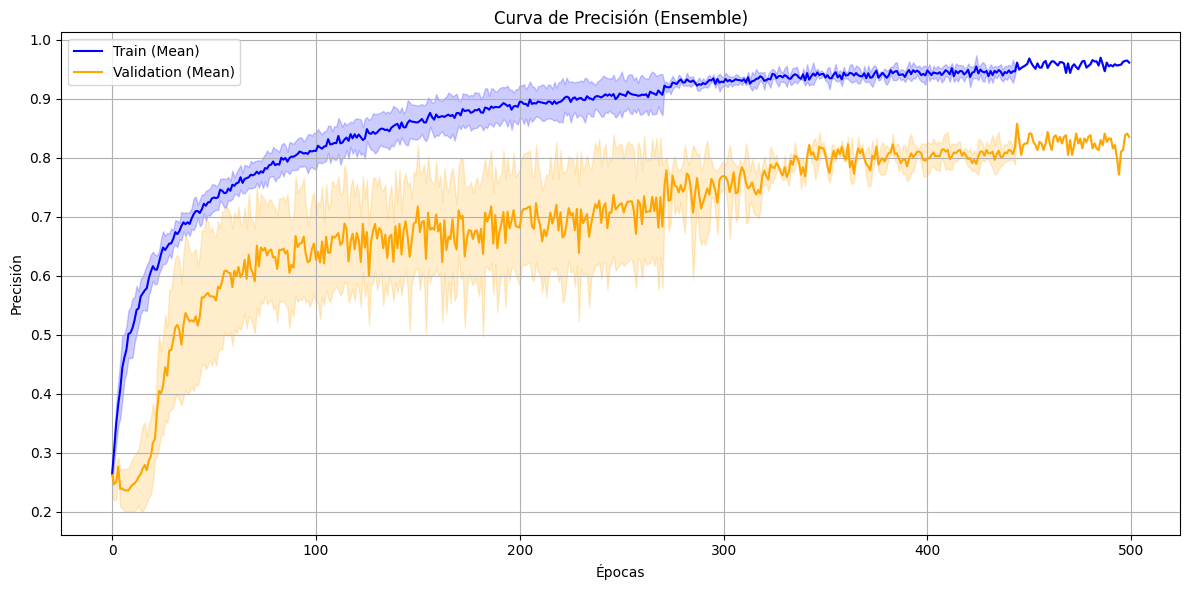

In [24]:
plot_ensemble_curve(histories)

# Datos Circunferencial

## QCNN

### KFold

In [39]:
kf.get_n_splits(q_images_circ,labels_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images_circ,labels_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images_circ[train_idx], q_images_circ[val_idx]
    train_labels, val_labels = labels_circ[train_idx], labels_circ[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=4, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}_circ_4clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=256,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}_circ_4clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 1.40262, saving model to checkpoints\qcnn_fold1_circ_4clases.h5
6/6 - 1s - loss: 2.3337 - accuracy: 0.2722 - val_loss: 1.4026 - val_accuracy: 0.2981 - lr: 0.0010 - 817ms/epoch - 136ms/step
Epoch 2/500

Epoch 2: val_loss improved from 1.40262 to 1.40254, saving model to checkpoints\qcnn_fold1_circ_4clases.h5
6/6 - 0s - loss: 2.0790 - accuracy: 0.2659 - val_loss: 1.4025 - val_accuracy: 0.2730 - lr: 0.0010 - 246ms/epoch - 41ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 1.40254
6/6 - 0s - loss: 1.9213 - accuracy: 0.2812 - val_loss: 1.4093 - val_accuracy: 0.2646 - lr: 0.0010 - 210ms/epoch - 35ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.40254
6/6 - 0s - loss: 1.7781 - accuracy: 0.3064 - val_loss: 1.4127 - val_accuracy: 0.2479 - lr: 0.0010 - 213ms/epoch - 36ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 1.40254
6/6 - 0s - loss: 1.7519 - accuracy: 0.2959 - val_loss: 1.4181 - 

KeyboardInterrupt: 

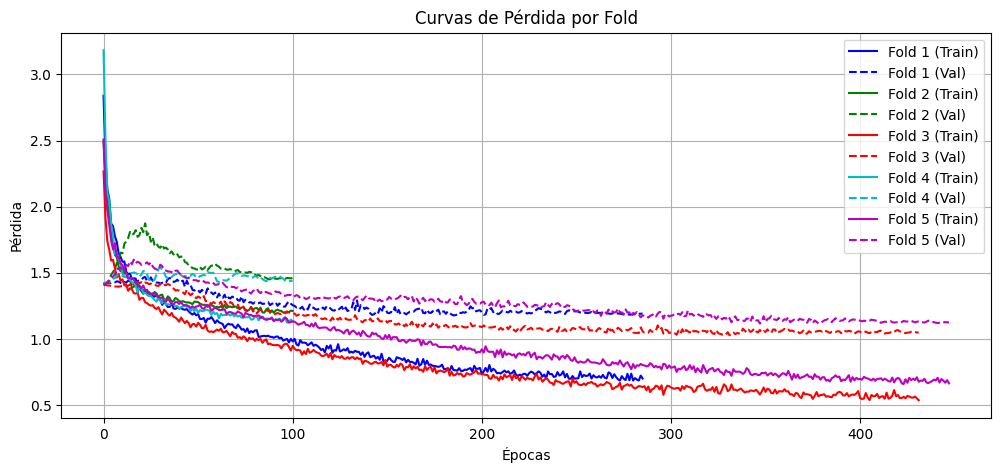

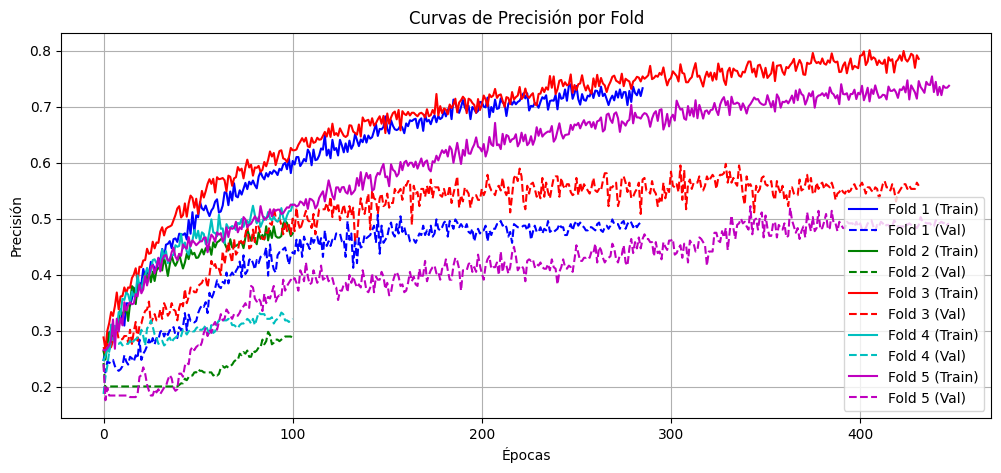

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [24]:
model_paths = [f"checkpoints/qcnn_fold{i+1}_circ_4clases.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}_circ_4clases.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [ ]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(q_test_images_circ)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels_circ.shape[1]):
        auc = roc_auc_score(test_labels_circ[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_circ[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels_circ, np.round(preds), average='micro')
    acc = accuracy_score(test_labels_circ, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 2...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 3...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 4...
7/7 [==============================] - 0s 3ms/step
Evaluando fold 5...
7/7 [==============================] - 0s 3ms/step


Graficando resultados del fold 1...


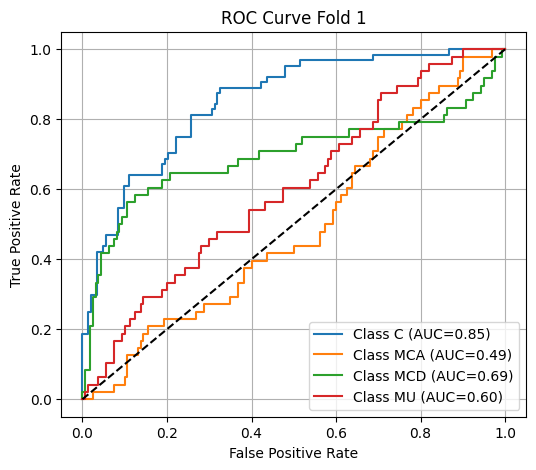

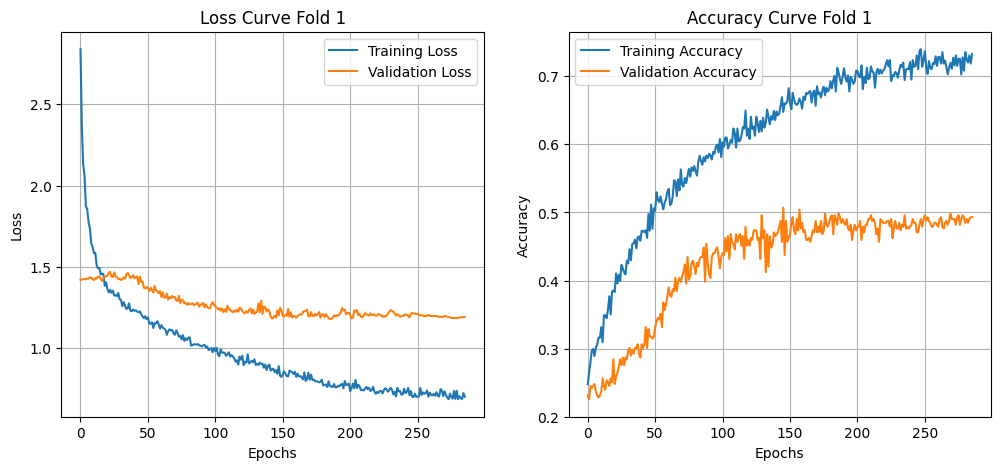

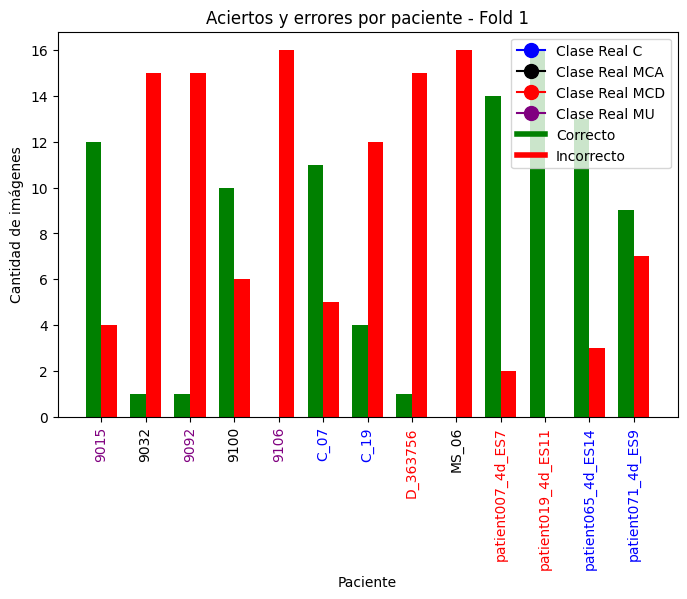

Graficando resultados del fold 2...


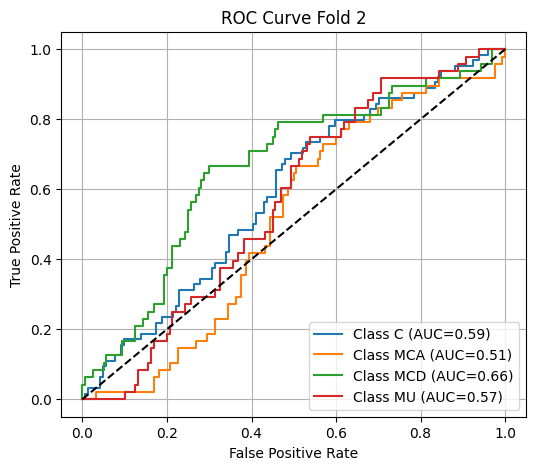

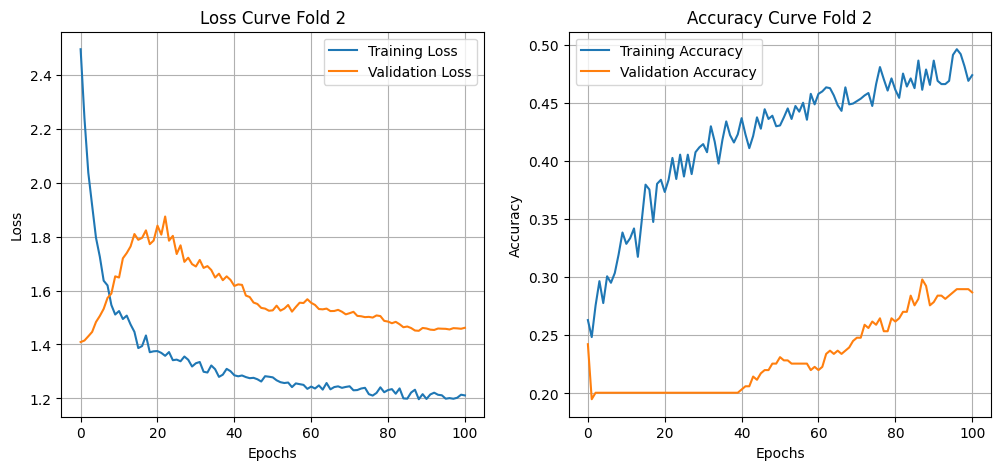

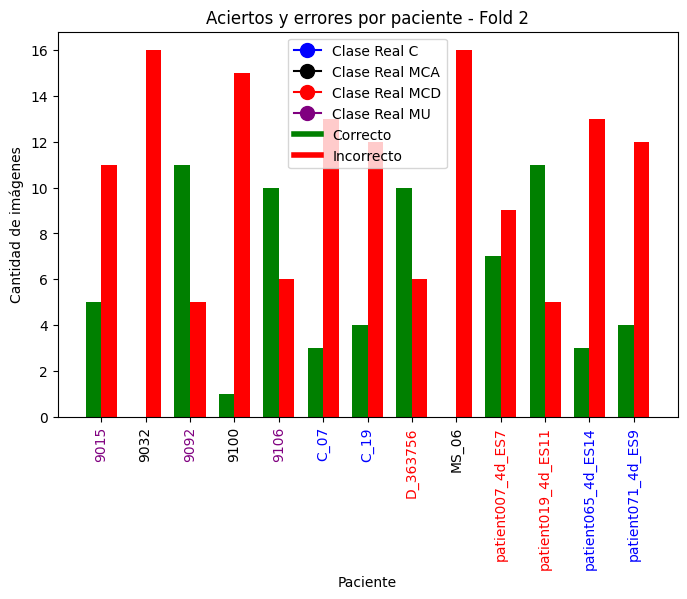

Graficando resultados del fold 3...


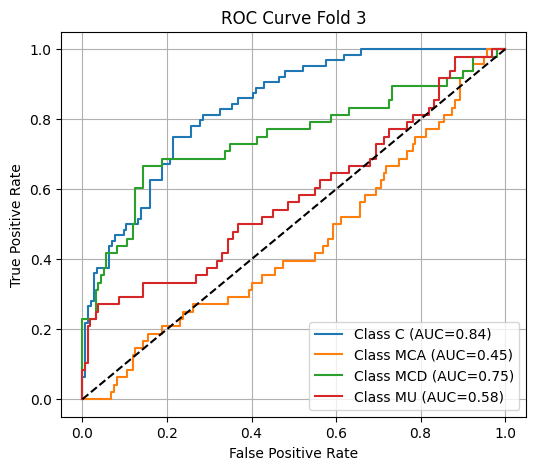

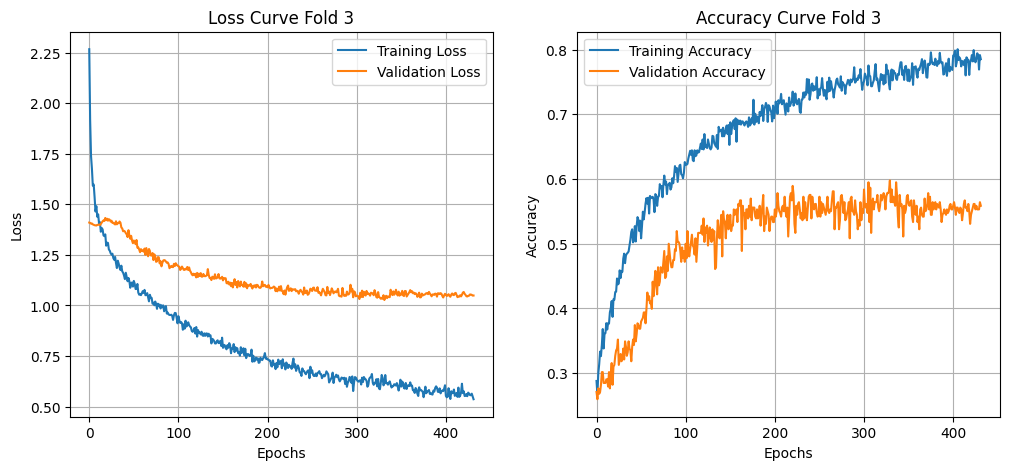

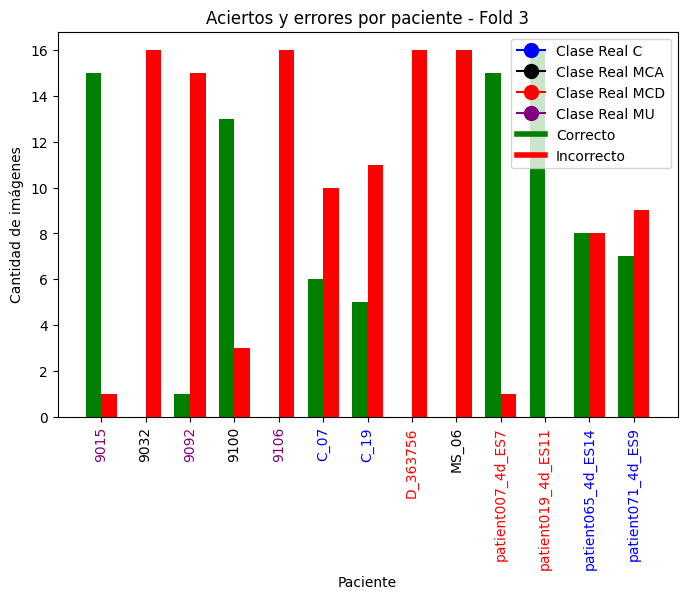

Graficando resultados del fold 4...


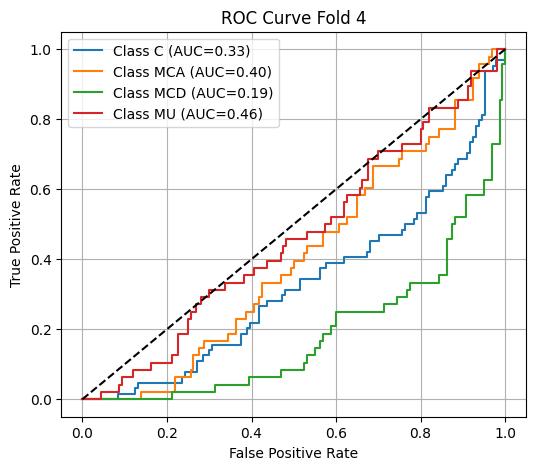

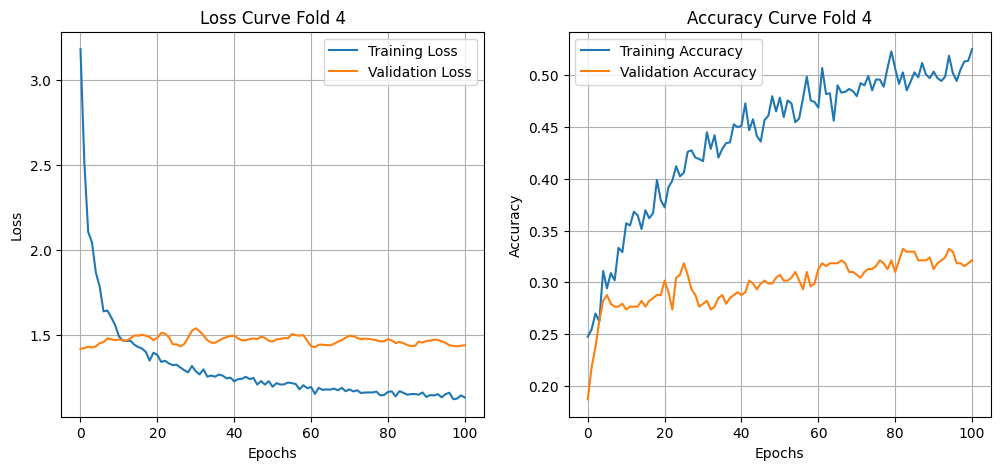

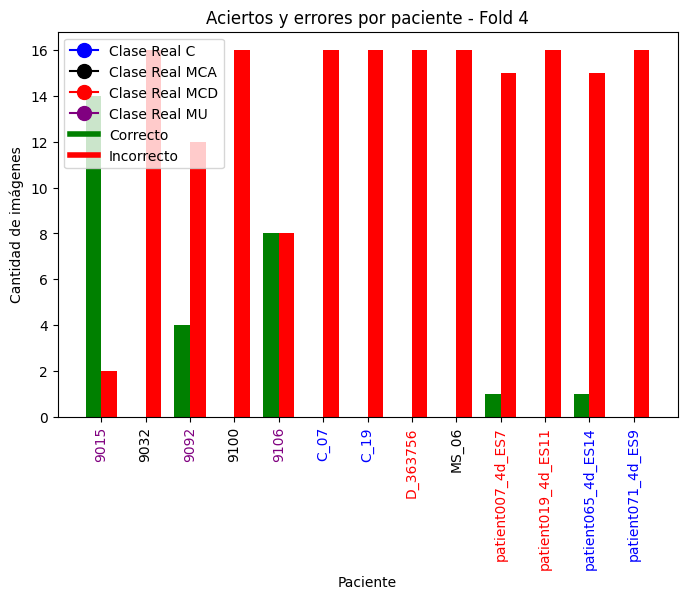

Graficando resultados del fold 5...


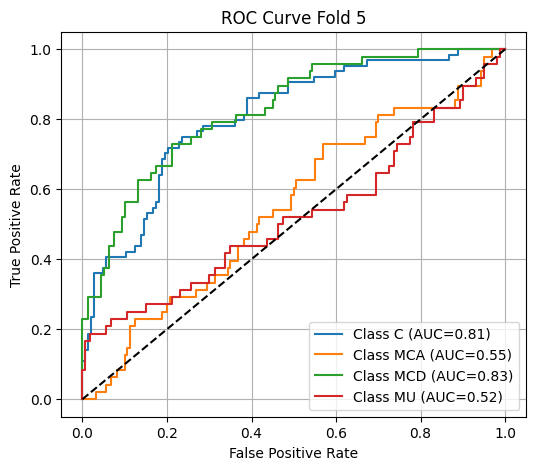

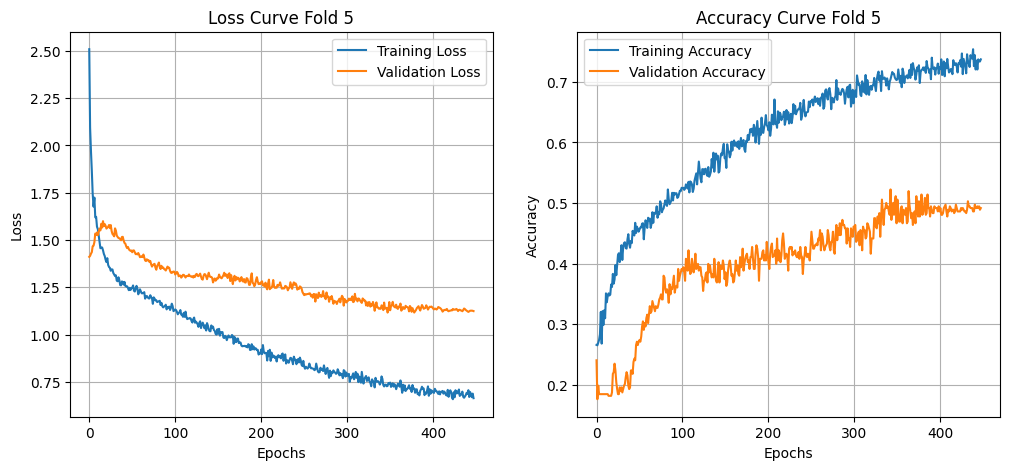

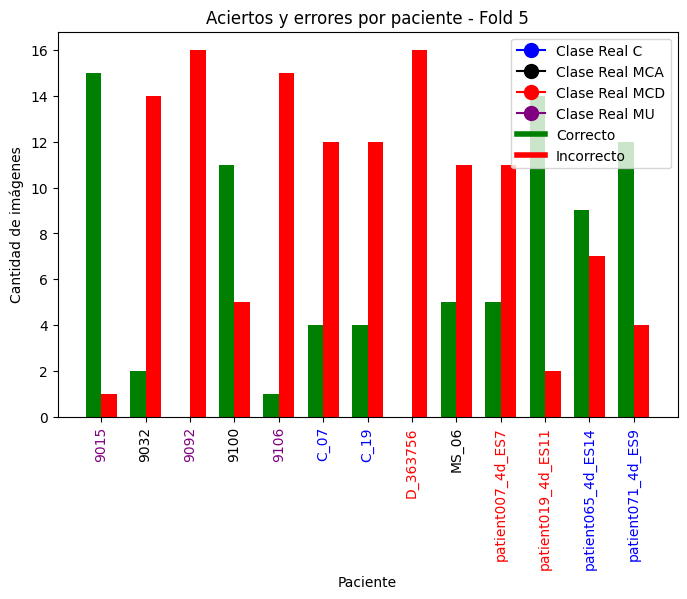

In [ ]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels_circ.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test_circ.copy()
    df["pred"] = [Encoder.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


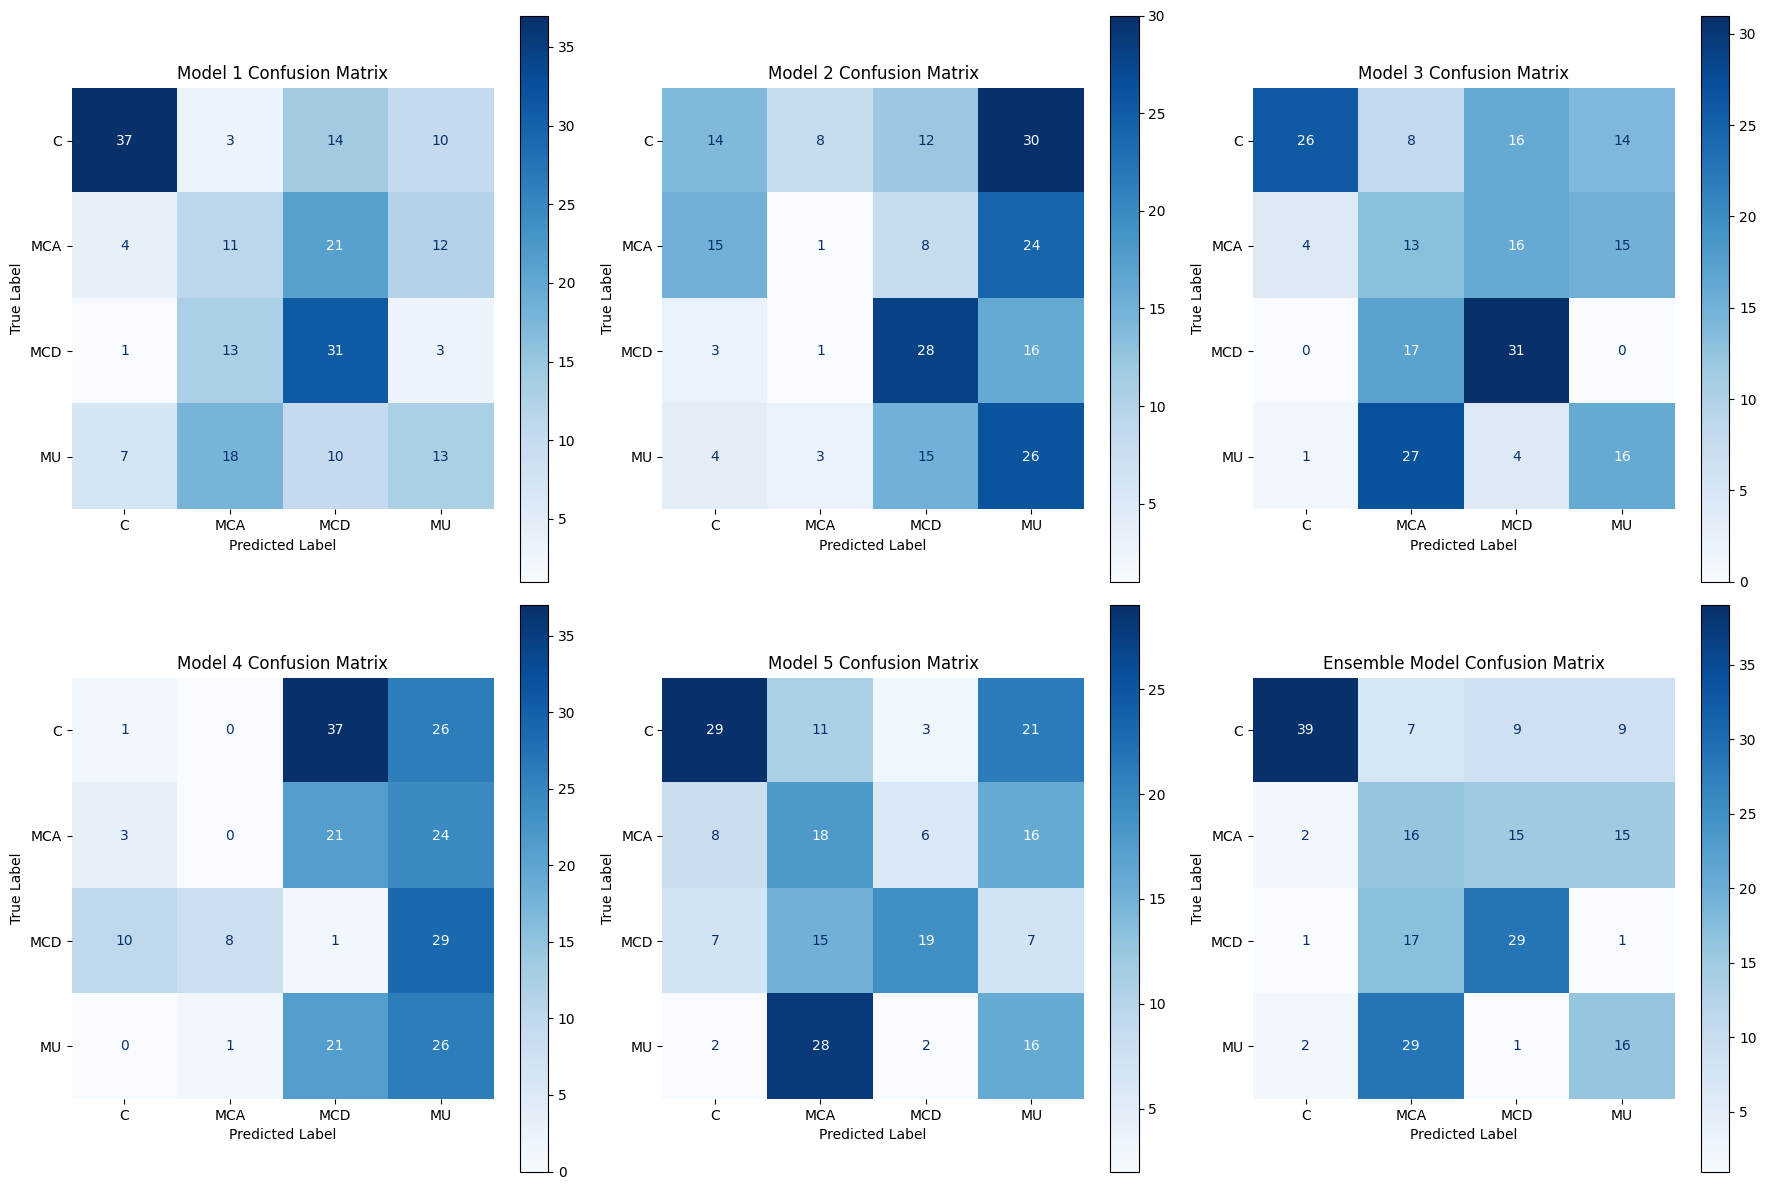

In [ ]:
plot_confusion_matrices(models, q_test_images_circ, test_labels_circ, class_names)

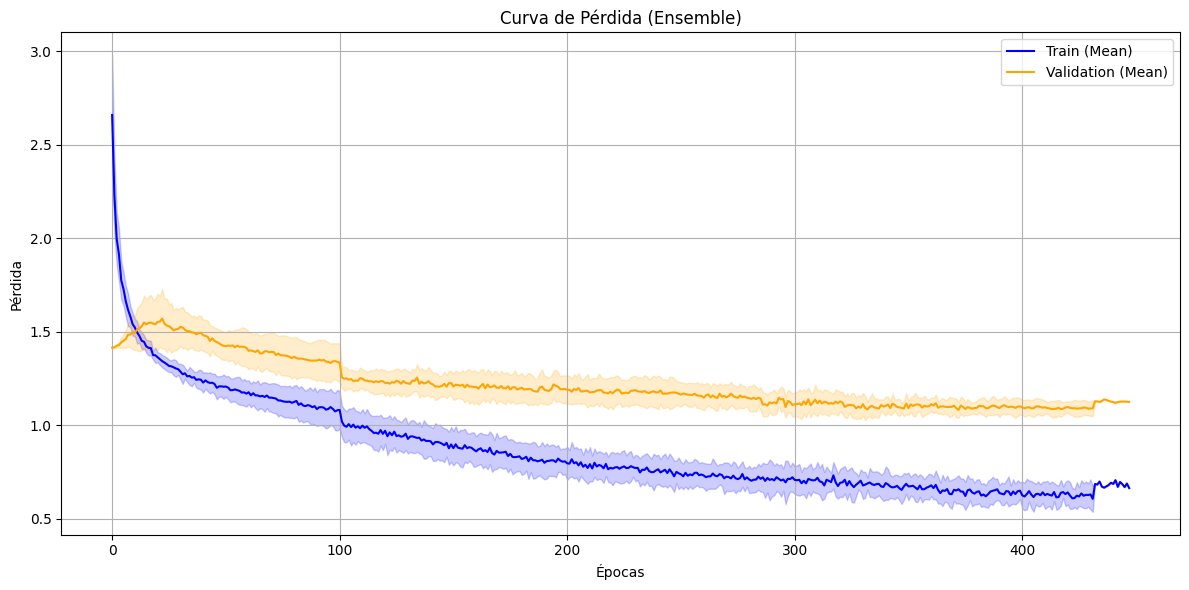

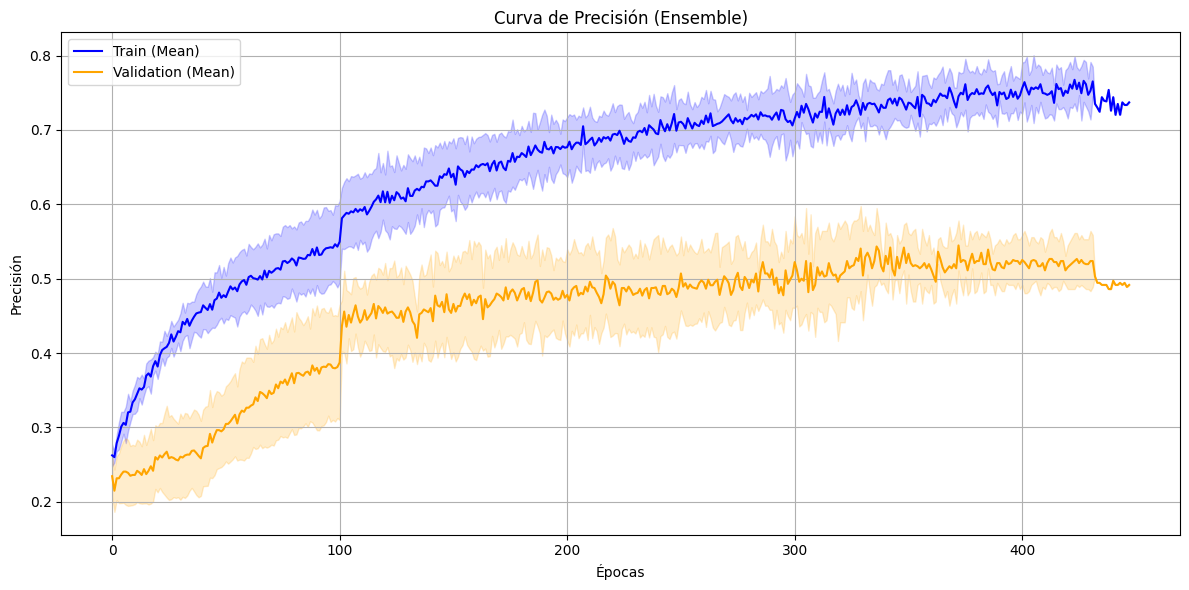

In [25]:
plot_ensemble_curve(histories)

## CNN

### KFold

In [ ]:
kf.get_n_splits(imgs_tf_circ,labels_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf_circ,labels_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf_circ[train_idx], imgs_tf_circ[val_idx]
    train_labels, val_labels = labels_circ[train_idx], labels_circ[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=4, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}_circ_4clases.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=256,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}_circ_4clases.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 1.41106, saving model to checkpoints\cnn_fold1_circ_4clases.h5
6/6 - 1s - loss: 3.0837 - accuracy: 0.2505 - val_loss: 1.4111 - val_accuracy: 0.3036 - lr: 0.0010 - 830ms/epoch - 138ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 1.41106
6/6 - 0s - loss: 2.2736 - accuracy: 0.2547 - val_loss: 1.4253 - val_accuracy: 0.2563 - lr: 0.0010 - 164ms/epoch - 27ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 1.41106
6/6 - 0s - loss: 1.8837 - accuracy: 0.3231 - val_loss: 1.4719 - val_accuracy: 0.2563 - lr: 0.0010 - 164ms/epoch - 27ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 1.41106
6/6 - 0s - loss: 1.7068 - accuracy: 0.3559 - val_loss: 1.4732 - val_accuracy: 0.2563 - lr: 0.0010 - 163ms/epoch - 27ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 1.41106
6/6 - 0s - loss: 1.6623 - accuracy: 0.3545 - val_loss: 1.5167 - val_accuracy: 0.2563 - lr: 0.0010 - 163ms/epoch - 27ms/step
E

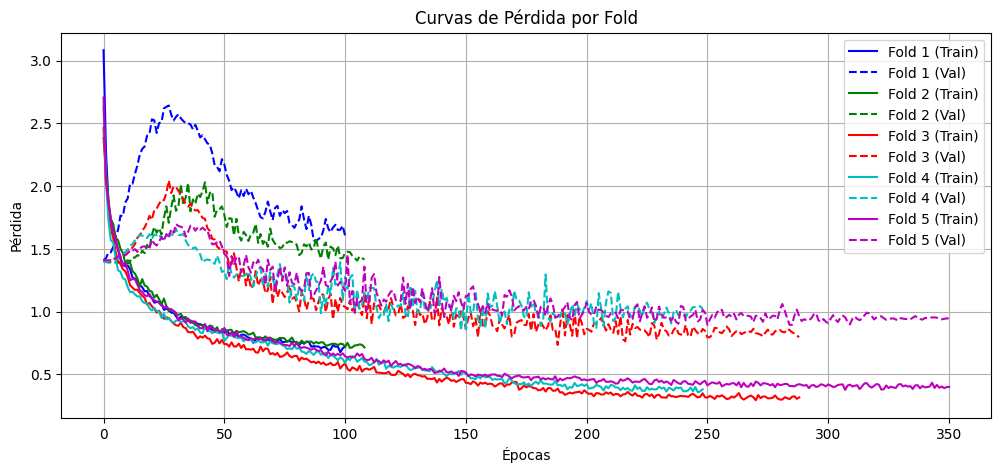

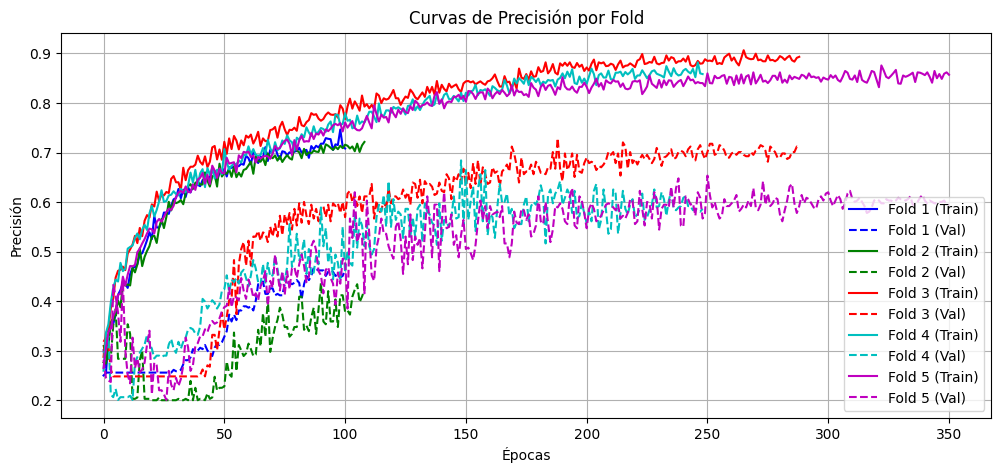

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [26]:
model_paths = [f"checkpoints/cnn_fold{i+1}_circ_4clases.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}_circ_4clases.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [ ]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(test_imgs_tf_circ)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels_circ.shape[1]):
        auc = roc_auc_score(test_labels_circ[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_circ[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels_circ, np.round(preds), average='micro')
    acc = accuracy_score(test_labels_circ, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
7/7 [==============================] - 0s 1ms/step
Evaluando fold 2...
7/7 [==============================] - 0s 1ms/step
Evaluando fold 3...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 4...
7/7 [==============================] - 0s 2ms/step
Evaluando fold 5...
7/7 [==============================] - 0s 2ms/step


Graficando resultados del fold 1...


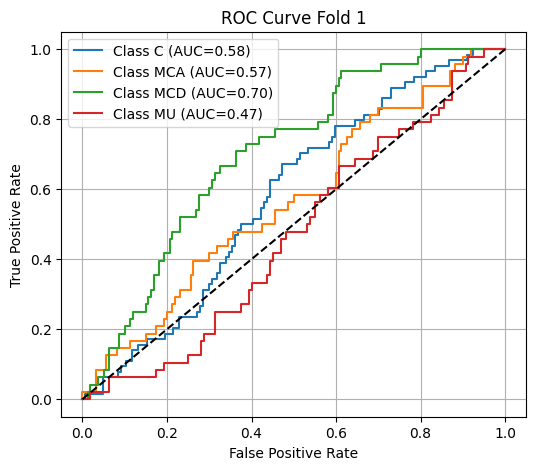

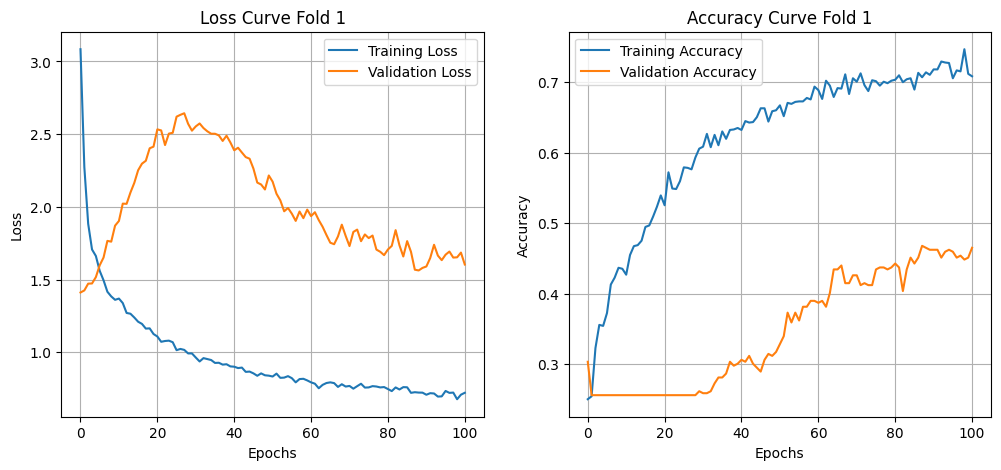

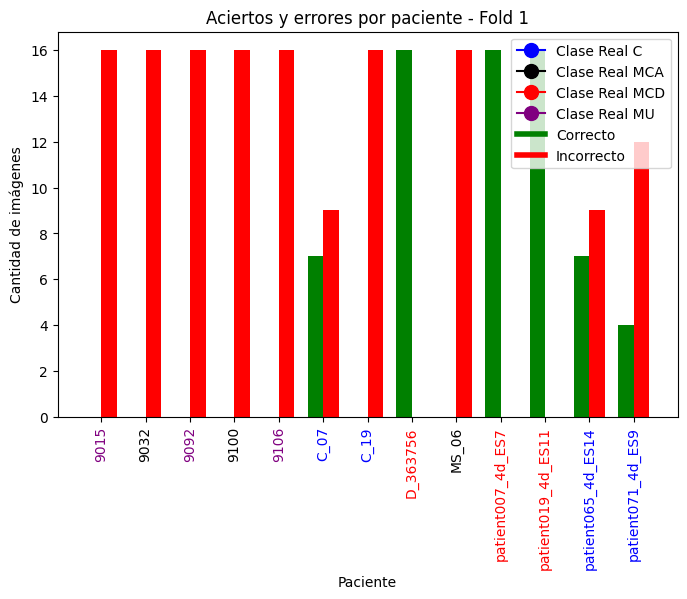

Graficando resultados del fold 2...


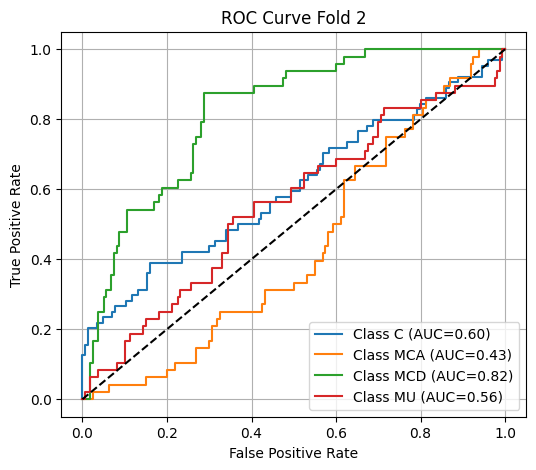

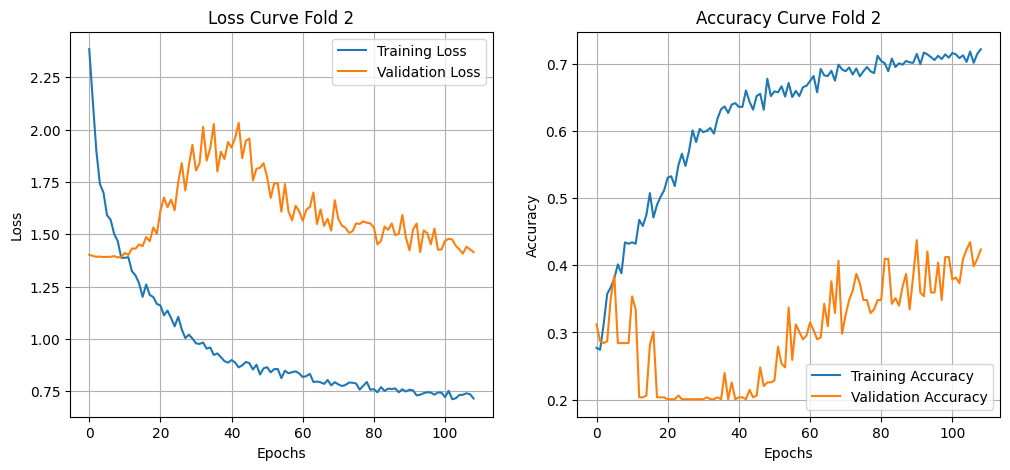

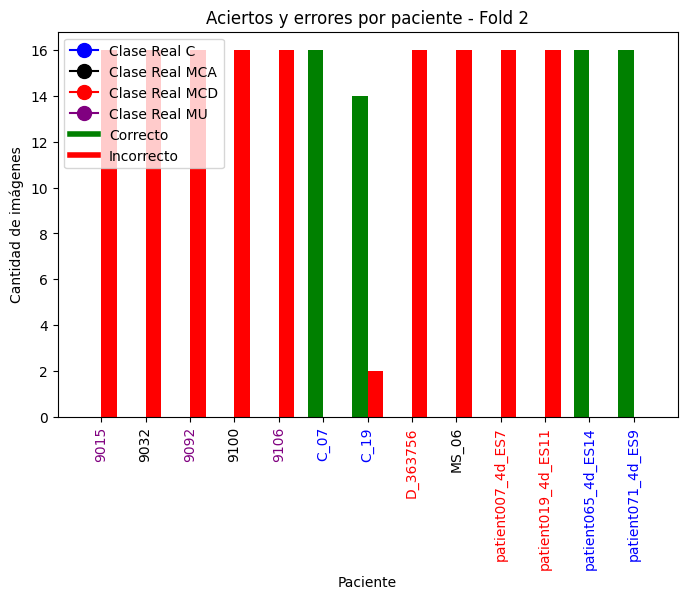

Graficando resultados del fold 3...


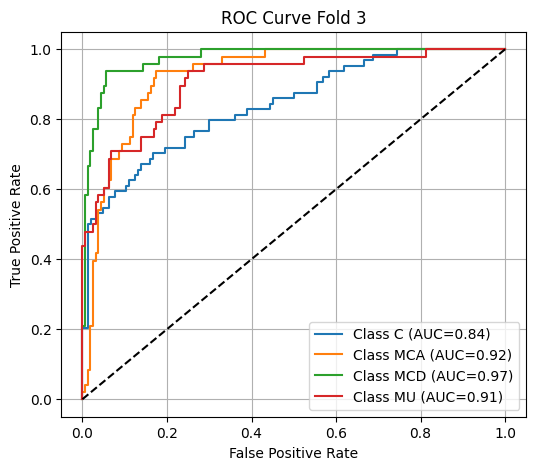

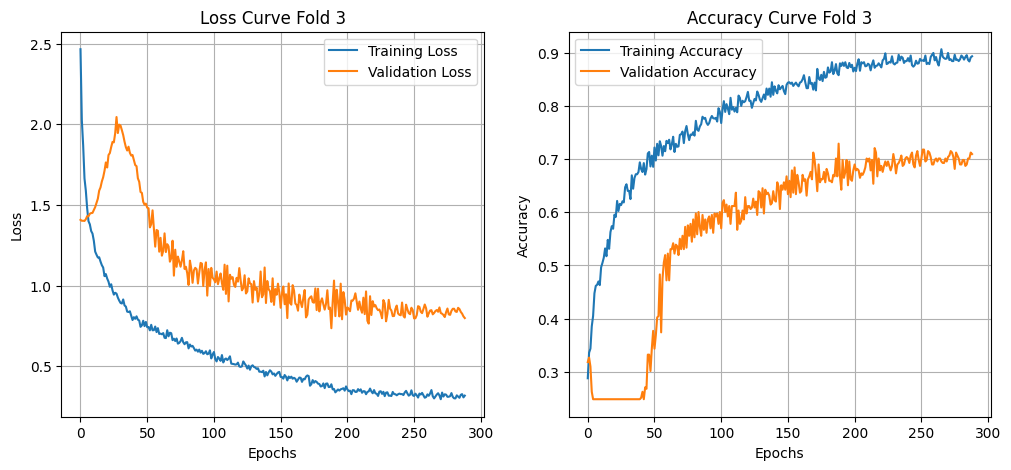

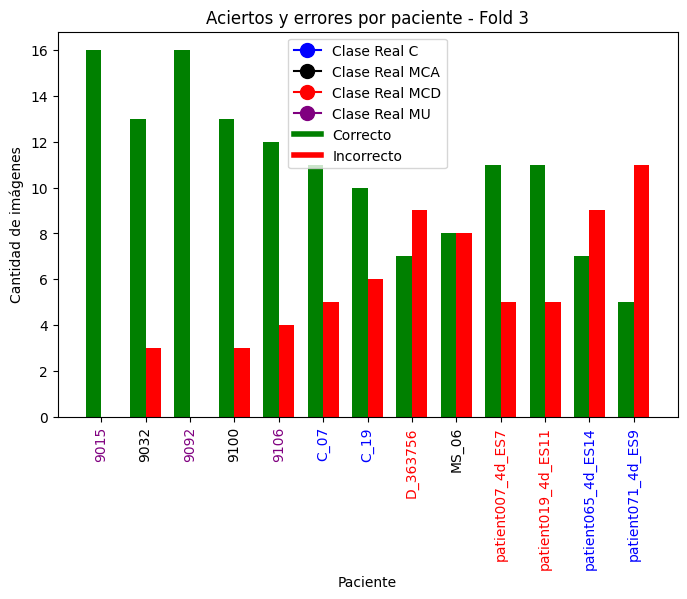

Graficando resultados del fold 4...


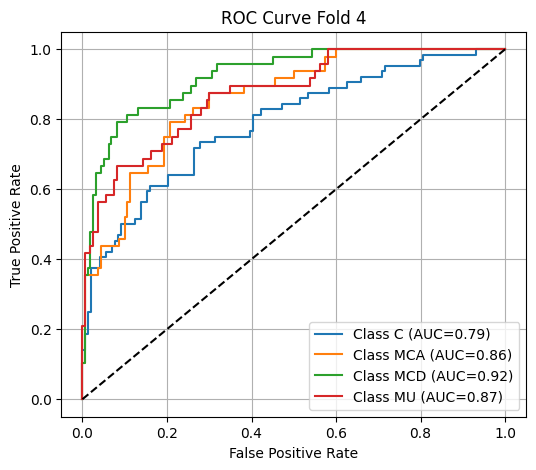

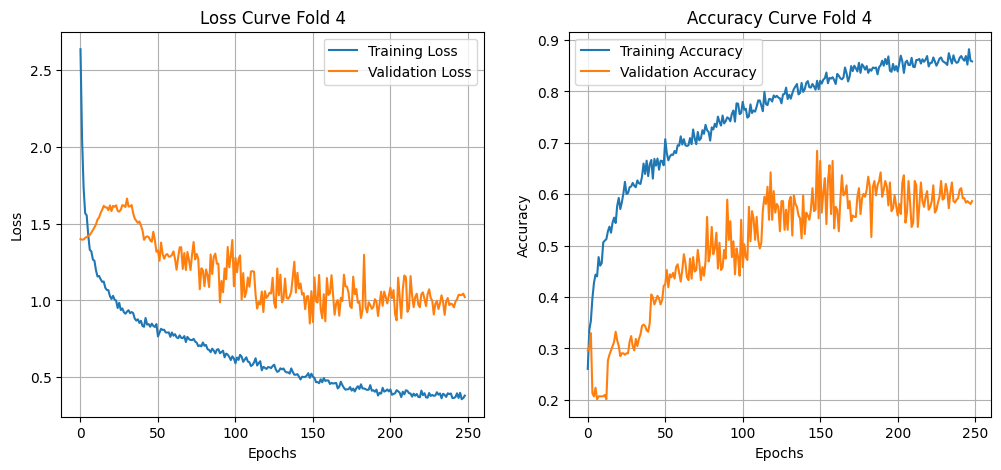

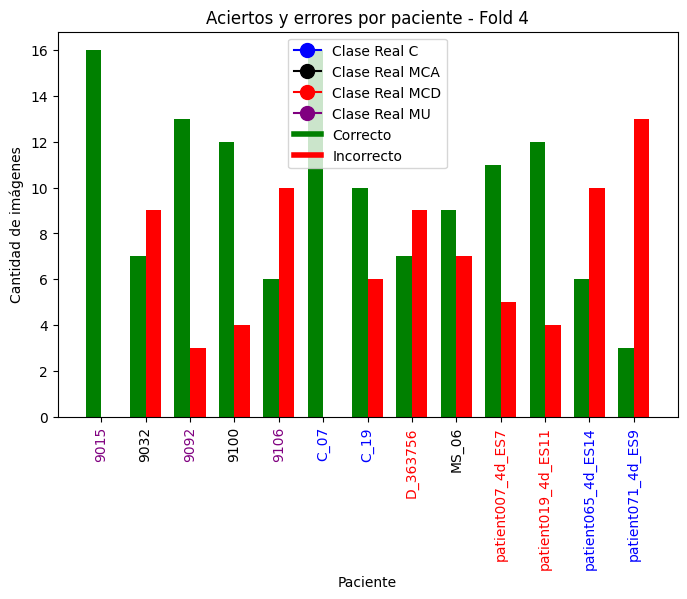

Graficando resultados del fold 5...


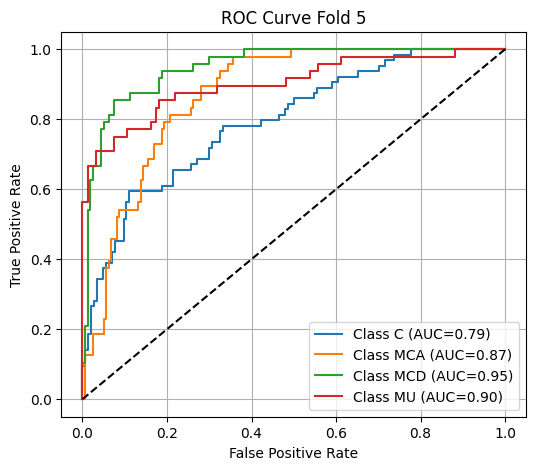

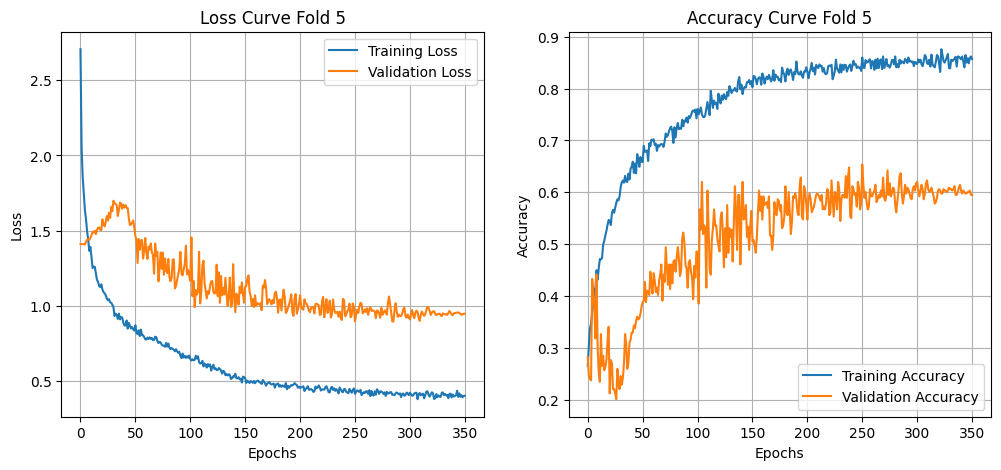

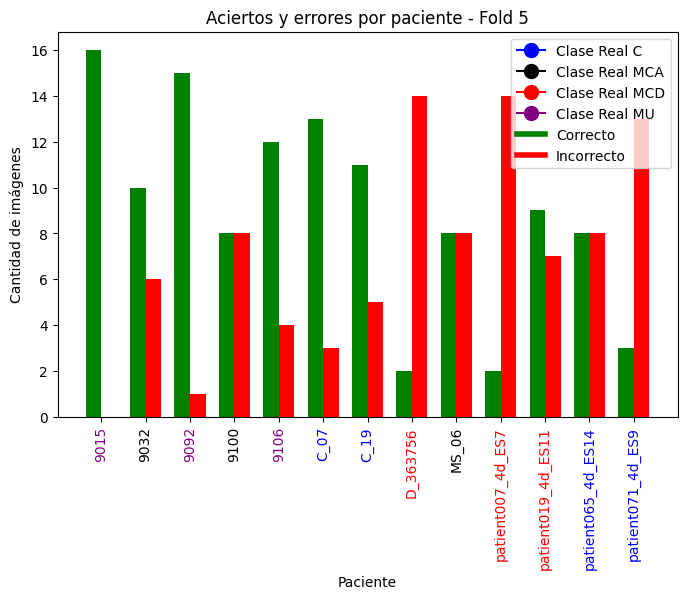

In [ ]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels_circ.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test_circ.copy()
    df["pred"] = [Encoder.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


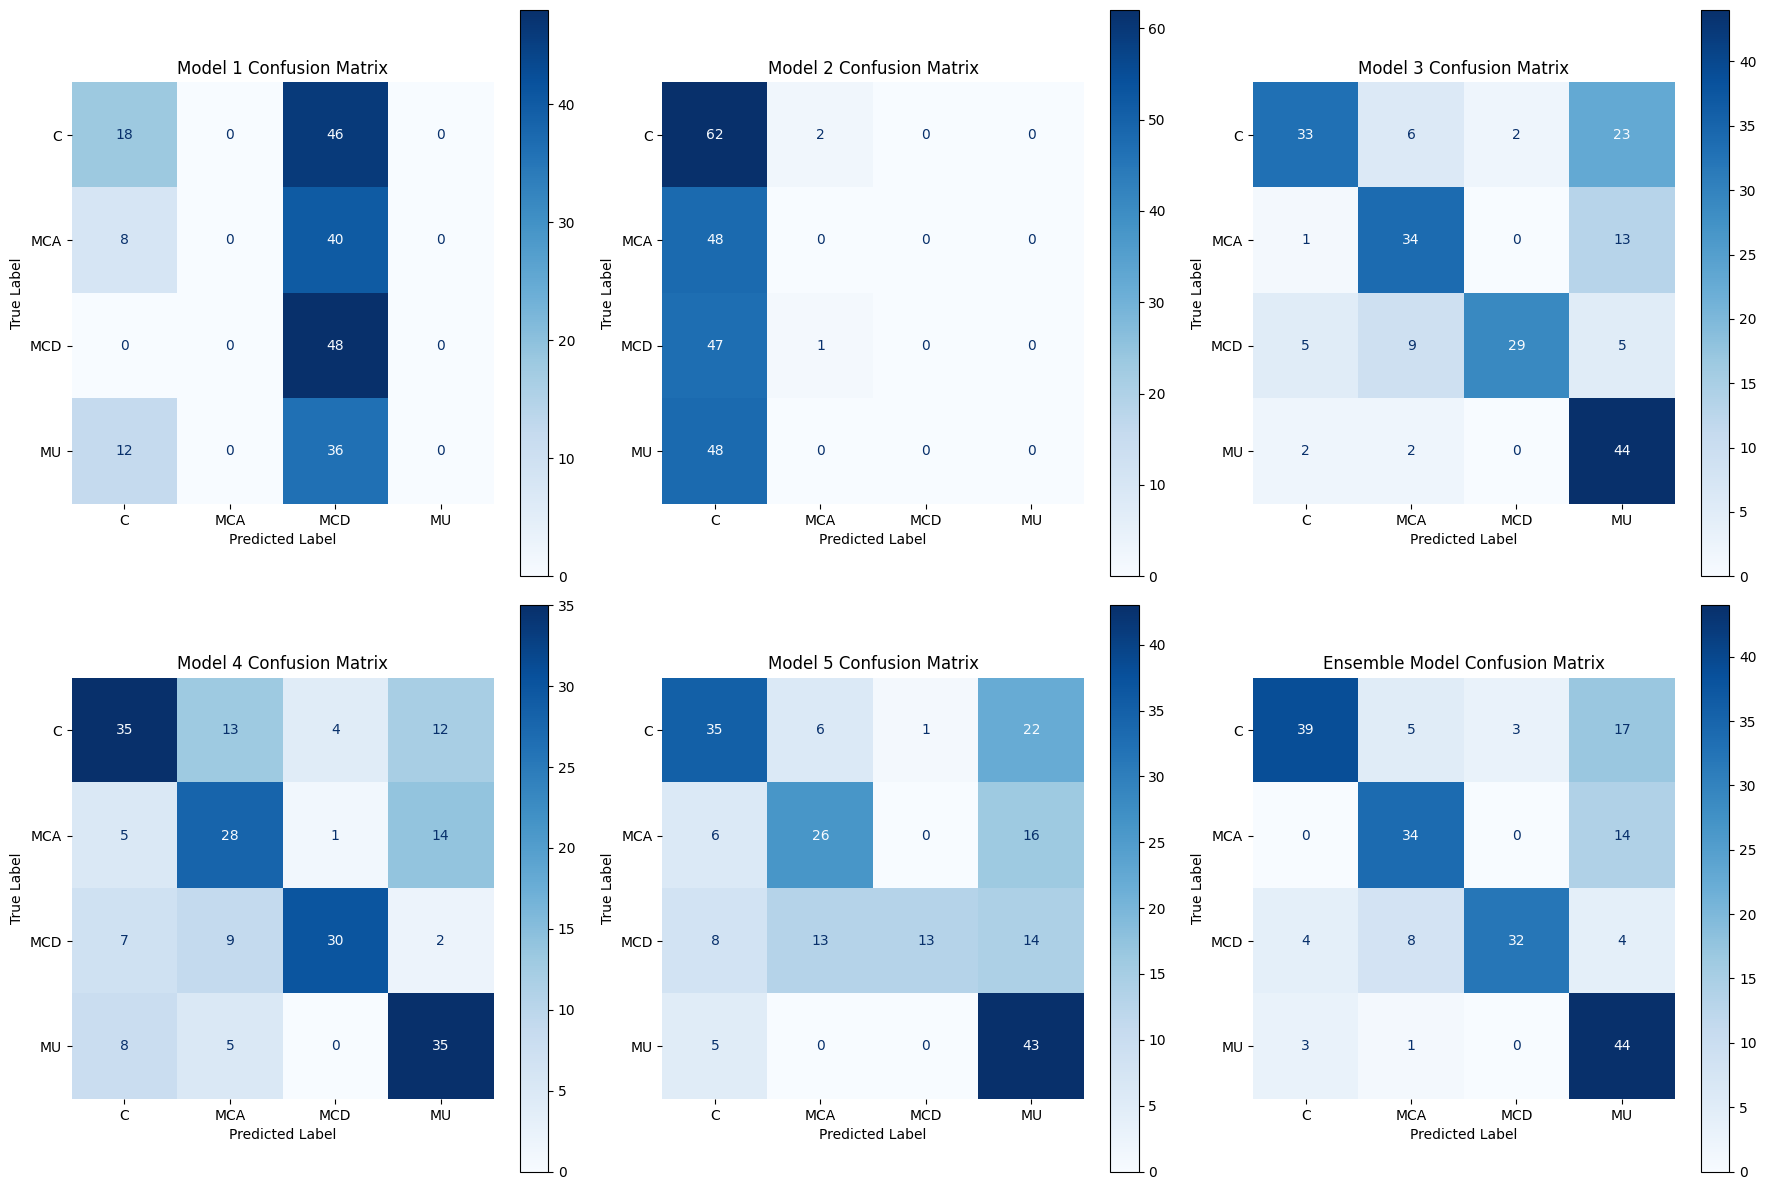

In [ ]:
plot_confusion_matrices(models, test_imgs_tf_circ, test_labels_rad, class_names)

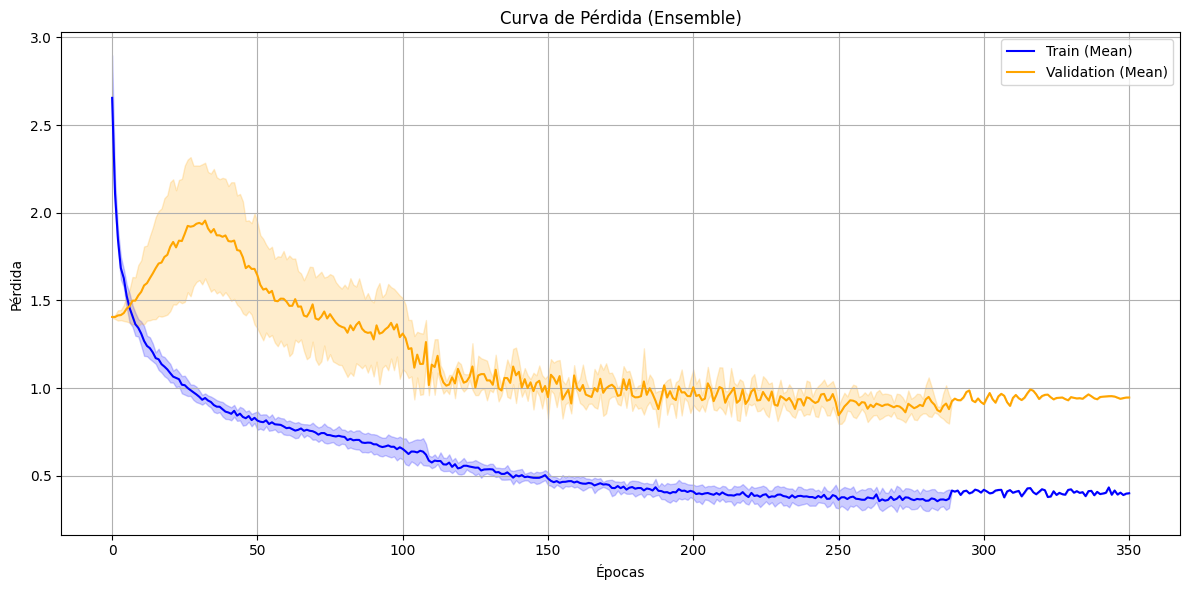

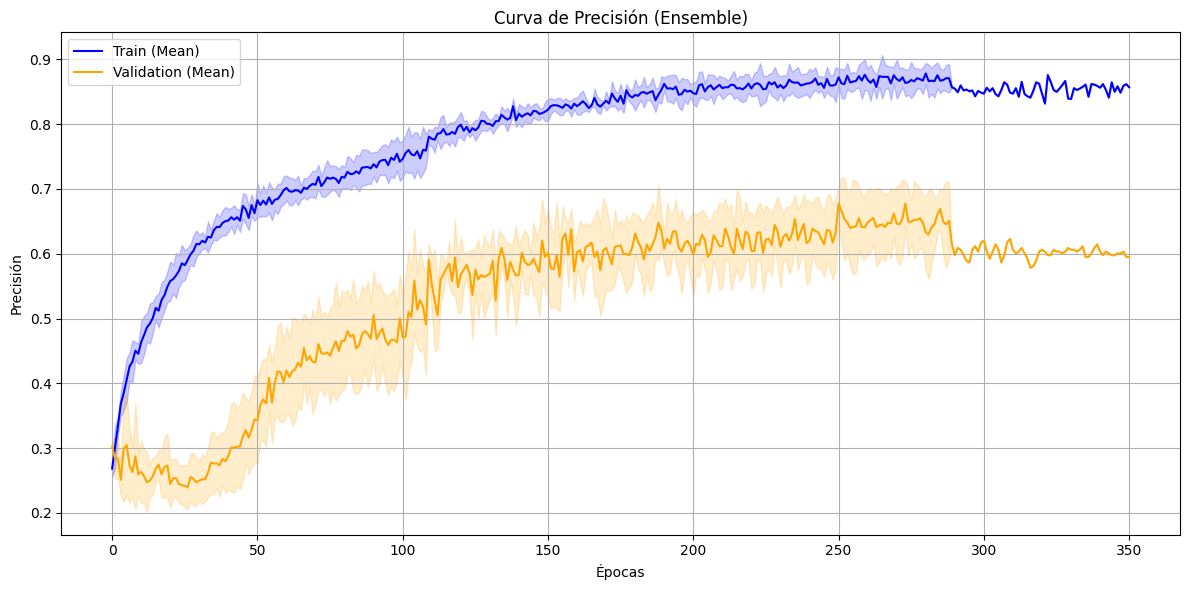

In [27]:
plot_ensemble_curve(histories)